# B1 — ResNet50 + MC Dropout (T=30), corrected v3.3

# B1 — ResNet50 + MC Dropout (T=30) experiment pipeline

- ResNet50 backbone
- standard softmax cross-entropy
- MC Dropout, **T=30**
- dropout **p=0.5** immediately before the final classifier
- 3 classes: benign / indeterminate / malignant
- 224×224 grayscale input replicated to 3 channels
- AdamW (β1=0.9, β2=0.999, weight decay=0.01)
- cosine annealing 1e-4 → 1e-6
- max 50 epochs
- early stopping patience 10 on validation Brier Score
- patient-level 5-fold cross-validation
- 10% of training patients reserved for validation where feasible
- seed 42
- evaluation: Macro-F1, macro OVR AUROC, Brier Score, ECE (15 bins), NLL
- MC predictive entropy uncertainty + rejection curves
- Grad-CAM
- latency, FLOPs, parameter count
- fold-wise outputs and 5-fold mean ± SD
- Wilcoxon comparison helper for later B1-vs-B3/C1 comparisons

### XAI mask requirement
Grad-CAM images can be generated from patches alone. Pointing Game, Insertion/Deletion AUC, and boundary-distance evaluation require **patch-aligned radiologist contour masks**. If a `mask_path` column is later added to metadata, the notebook can evaluate them; otherwise it records those metrics as unavailable.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#@title 1. Install dependencies
!pip -q install scikit-learn scipy matplotlib pandas pillow tqdm thop

In [3]:
#@title 2. Imports and global configuration
import os, json, math, time, copy, random, warnings, gc, hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import wilcoxon

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.model_selection import StratifiedGroupKFold, GroupKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss, confusion_matrix
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm
from thop import profile

warnings.filterwarnings('ignore')

PILOT_MAX_PATIENTS = None   # overwritten from authoritative preprocessing config in Cell 6
SEED = 42
NUM_CLASSES = 3
CLASS_NAMES = ['benign', 'indeterminate', 'malignant']
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
LEARNING_RATE = 1e-4
MIN_LEARNING_RATE = 1e-6
WEIGHT_DECAY = 0.01
MC_T = 30
DROPOUT_P = 0.5
ECE_BINS = 15

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [4]:
#@title 3. Reproducibility
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
seed_everything(SEED)

In [5]:
#@title 4. Mount Google Drive and create the professor-approved experiment folder structure

MYDRIVE = Path('/content/drive/MyDrive')
THESIS_ROOT = MYDRIVE / 'Thesis_Work' / 'LIDC_Thesis'
LIDC_ROOT = THESIS_ROOT / 'LIDC'
PROCESSED_ROOT = LIDC_ROOT / 'processed'
PATCH_ROOT = PROCESSED_ROOT / 'patches'
METADATA_ROOT = PROCESSED_ROOT / 'metadata'
PREPROCESS_CONFIG = LIDC_ROOT / 'preprocessing' / 'configs' / 'preprocessing_config.yaml'
SHARED_RUN_CONFIG = METADATA_ROOT / 'shared_pipeline_config.json'
FOLD_ASSIGNMENTS_CSV = METADATA_ROOT / 'fold_assignments.csv'
FOLD_HASH_FILE = METADATA_ROOT / 'fold_assignments.sha256'
CLASS_MAPPING_JSON = LIDC_ROOT / 'preprocessing' / 'configs' / 'class_mapping.json'

# All B1 outputs stay below the B1 experiment folder, using folder.rtf subfolders.
B1_ROOT = THESIS_ROOT / 'experiments' / 'B1_ResNet50_MC_Dropout_T30'
NOTEBOOK_ROOT = B1_ROOT / 'notebooks'
CONFIG_ROOT = B1_ROOT / 'configs'
SPLIT_ROOT = B1_ROOT / 'splits'
CHECKPOINT_ROOT = B1_ROOT / 'checkpoints'
PREDICTION_ROOT = B1_ROOT / 'predictions'
DET_PRED_ROOT = PREDICTION_ROOT / 'deterministic'
MC_PRED_ROOT = PREDICTION_ROOT / 'mc_dropout_T30'
METRICS_ROOT = B1_ROOT / 'metrics'
CLASS_METRICS_ROOT = METRICS_ROOT / 'classification'
CAL_METRICS_ROOT = METRICS_ROOT / 'calibration'
UNC_METRICS_ROOT = METRICS_ROOT / 'uncertainty'
EFF_METRICS_ROOT = METRICS_ROOT / 'efficiency'
GRADCAM_ROOT = B1_ROOT / 'gradcam'
PLOT_ROOT = B1_ROOT / 'plots'
TRAIN_PLOT_ROOT = PLOT_ROOT / 'training_curves'
CM_PLOT_ROOT = PLOT_ROOT / 'confusion_matrices'
ROC_PLOT_ROOT = PLOT_ROOT / 'roc_curves'
CAL_PLOT_ROOT = PLOT_ROOT / 'calibration_diagrams'
REL_PLOT_ROOT = PLOT_ROOT / 'reliability_diagrams'
REJ_PLOT_ROOT = PLOT_ROOT / 'rejection_curves'
LOG_ROOT = B1_ROOT / 'logs'
REPORT_ROOT = B1_ROOT / 'reports'

for p in [NOTEBOOK_ROOT, CONFIG_ROOT, SPLIT_ROOT, CHECKPOINT_ROOT, DET_PRED_ROOT, MC_PRED_ROOT,
          CLASS_METRICS_ROOT, CAL_METRICS_ROOT, UNC_METRICS_ROOT, EFF_METRICS_ROOT,
          GRADCAM_ROOT, TRAIN_PLOT_ROOT, CM_PLOT_ROOT, ROC_PLOT_ROOT, CAL_PLOT_ROOT,
          REL_PLOT_ROOT, REJ_PLOT_ROOT, LOG_ROOT, REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)
for fold in range(1, 6):
    for root in [SPLIT_ROOT, CHECKPOINT_ROOT, GRADCAM_ROOT]:
        (root / f'fold_{fold}').mkdir(parents=True, exist_ok=True)

METADATA_CSV = METADATA_ROOT / 'lidc_patches_metadata.csv'
DETAILED_METADATA_CSV = METADATA_ROOT / 'detailed_nodule_metadata.csv'

assert METADATA_CSV.exists(), f'Missing preprocessing metadata: {METADATA_CSV}'
assert PREPROCESS_CONFIG.exists(), f'Missing preprocessing config: {PREPROCESS_CONFIG}'
assert CLASS_MAPPING_JSON.exists(), f'Missing class mapping: {CLASS_MAPPING_JSON}'
assert SHARED_RUN_CONFIG.exists(), f'Missing shared preprocessing run config: {SHARED_RUN_CONFIG}'
assert FOLD_ASSIGNMENTS_CSV.exists(), f'Missing authoritative fold file: {FOLD_ASSIGNMENTS_CSV}'
assert FOLD_HASH_FILE.exists(), f'Missing authoritative fold hash: {FOLD_HASH_FILE}'
print('Authoritative preprocessing root:', LIDC_ROOT)
print('B1 experiment root:', B1_ROOT)


Authoritative preprocessing root: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC
B1 experiment root: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30


In [6]:
#@title 6. Load and validate authoritative preprocessing metadata/config/fold hash
import yaml

with open(PREPROCESS_CONFIG) as f:
    PRE_CFG = yaml.safe_load(f)
with open(CLASS_MAPPING_JSON) as f:
    PRE_CLASS_MAP = json.load(f)
with open(SHARED_RUN_CONFIG) as f:
    SHARED_CFG = json.load(f)

expected_map = {'benign': 0, 'indeterminate': 1, 'malignant': 2}
assert PRE_CLASS_MAP == expected_map, f'Class mapping mismatch: {PRE_CLASS_MAP}'
assert PRE_CFG['selection']['minimum_diameter_mm'] == 3.0
assert PRE_CFG['selection']['minimum_radiologists'] == 3
assert PRE_CFG['labels']['num_classes'] == 3
assert PRE_CFG['variance']['type'] == 'population'
assert PRE_CFG['variance']['normalizer'] == 4.0
assert PRE_CFG['crop_geometry']['output_size_px'] == 224
assert PRE_CFG['crop_geometry']['target_spacing_mm'] == 1.0
assert PRE_CFG['crop_geometry']['field_of_view_mm'] == 64.0
assert PRE_CFG['crop_geometry']['hu_low'] == -1000.0 and PRE_CFG['crop_geometry']['hu_high'] == 400.0
assert PRE_CFG['cross_validation']['folds'] == 5

# One pilot/full-run switch: B1 must inherit it; never override locally.
PILOT_MAX_PATIENTS = SHARED_CFG.get('PILOT_MAX_PATIENTS', None)
FORMAL_RUN = PILOT_MAX_PATIENTS is None

# Verify the exact shared fold file bytes against both the sidecar and run config.
actual_fold_sha256 = hashlib.sha256(FOLD_ASSIGNMENTS_CSV.read_bytes()).hexdigest()
expected_fold_sha256 = FOLD_HASH_FILE.read_text().strip()
assert actual_fold_sha256 == expected_fold_sha256, 'fold_assignments.csv SHA-256 does not match sidecar.'
assert SHARED_CFG.get('fold_assignments_sha256') == actual_fold_sha256, 'Shared run config fold hash mismatch.'

fold_df = pd.read_csv(FOLD_ASSIGNMENTS_CSV, dtype={'patient_id': str})
fold_df['patient_id'] = fold_df['patient_id'].astype(str).str.strip()
fold_df['fold'] = pd.to_numeric(fold_df['fold'], errors='raise').astype(int)
assert not fold_df['patient_id'].duplicated().any(), 'fold_assignments.csv must contain one row per patient.'
assert set(fold_df['fold'].unique()).issubset({1,2,3,4,5})

df = pd.read_csv(METADATA_CSV, dtype={'patient_id': str})
required = {
    'nodule_id','patient_id','label_name','label_id','patch_path',
    'variance_normalized','malignancy_scores','q_benign','q_indeterminate','q_malignant'
}
missing = required - set(df.columns)
if missing:
    raise RuntimeError(f'Authoritative metadata is missing required columns: {sorted(missing)}')

df['patient_id'] = df['patient_id'].astype(str).str.strip()
df = df.drop(columns=['fold'], errors='ignore').merge(
    fold_df, on='patient_id', how='left', validate='many_to_one'
)
if df['fold'].isna().any():
    raise RuntimeError('Some metadata patients are missing from fold_assignments.csv.')

df['fold'] = df['fold'].astype(int)
df['label'] = pd.to_numeric(df['label_id'], errors='raise').astype(int)
df['class_name'] = df['label_name'].astype(str).str.lower()
df['image_path'] = df['patch_path'].astype(str)
df['V'] = pd.to_numeric(df['variance_normalized'], errors='raise').astype(float)

assert set(df['label'].unique()).issubset({0,1,2})
assert (df.apply(lambda r: expected_map[r['class_name']] == r['label'], axis=1)).all()
assert df.groupby('patient_id')['fold'].nunique().max() == 1
assert df['V'].between(0,1).all()

exists = df['image_path'].map(lambda p: Path(p).is_file())
if not exists.all():
    raise RuntimeError(f'{int((~exists).sum())} authoritative patch file(s) do not exist.')

# The pilot subset was already selected by preprocessing. B1 does NOT select another subset.
if not FORMAL_RUN:
    warnings.warn(
        f'Authoritative preprocessing is PILOT mode (PILOT_MAX_PATIENTS={PILOT_MAX_PATIENTS}). '
        'Do not use these results for model selection, milestone pass/fail, or B-vs-C conclusions.'
    )

df.to_csv(METADATA_ROOT / 'B1_effective_metadata.csv', index=False)
print('Fold SHA-256:', actual_fold_sha256)
print('Formal run:', FORMAL_RUN, '| PILOT_MAX_PATIENTS:', PILOT_MAX_PATIENTS)
print('Patches:', len(df), '| Patients:', df.patient_id.nunique())
display(df.groupby(['fold','class_name']).size().unstack(fill_value=0))


Fold SHA-256: 6579bbae4001911dbeb74213340e7846c3dcc2d03f915ed501c0ec339446a060
Formal run: True | PILOT_MAX_PATIENTS: None
Patches: 48 | Patients: 21


class_name,benign,indeterminate,malignant
fold,,,
1,1,0,1
2,1,14,4
3,0,5,1
4,1,9,1
5,2,5,3


Path : /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/processed/patches/malignant/LIDC-IDRI-0001_S12_N000.npy
Shape: (224, 224)
Dtype: float32
Min  : 0.022858277
Max  : 1.0
/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/processed/patches/malignant/LIDC-IDRI-0015_S26_N000.npy 2 LIDC-IDRI-0015
/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/processed/patches/malignant/LIDC-IDRI-0023_S34_N000.npy 2 LIDC-IDRI-0023
/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/processed/patches/indeterminate/LIDC-IDRI-0014_S25_N000.npy 1 LIDC-IDRI-0014
/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/processed/patches/benign/LIDC-IDRI-0024_S35_N002.npy 0 LIDC-IDRI-0024
/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/processed/patches/indeterminate/LIDC-IDRI-0013_S24_N001.npy 1 LIDC-IDRI-0013
/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/processed/patches/malignant/LIDC-IDRI-0018_S29_N003.npy 2 LIDC-IDRI-0018
/content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/processed/patch

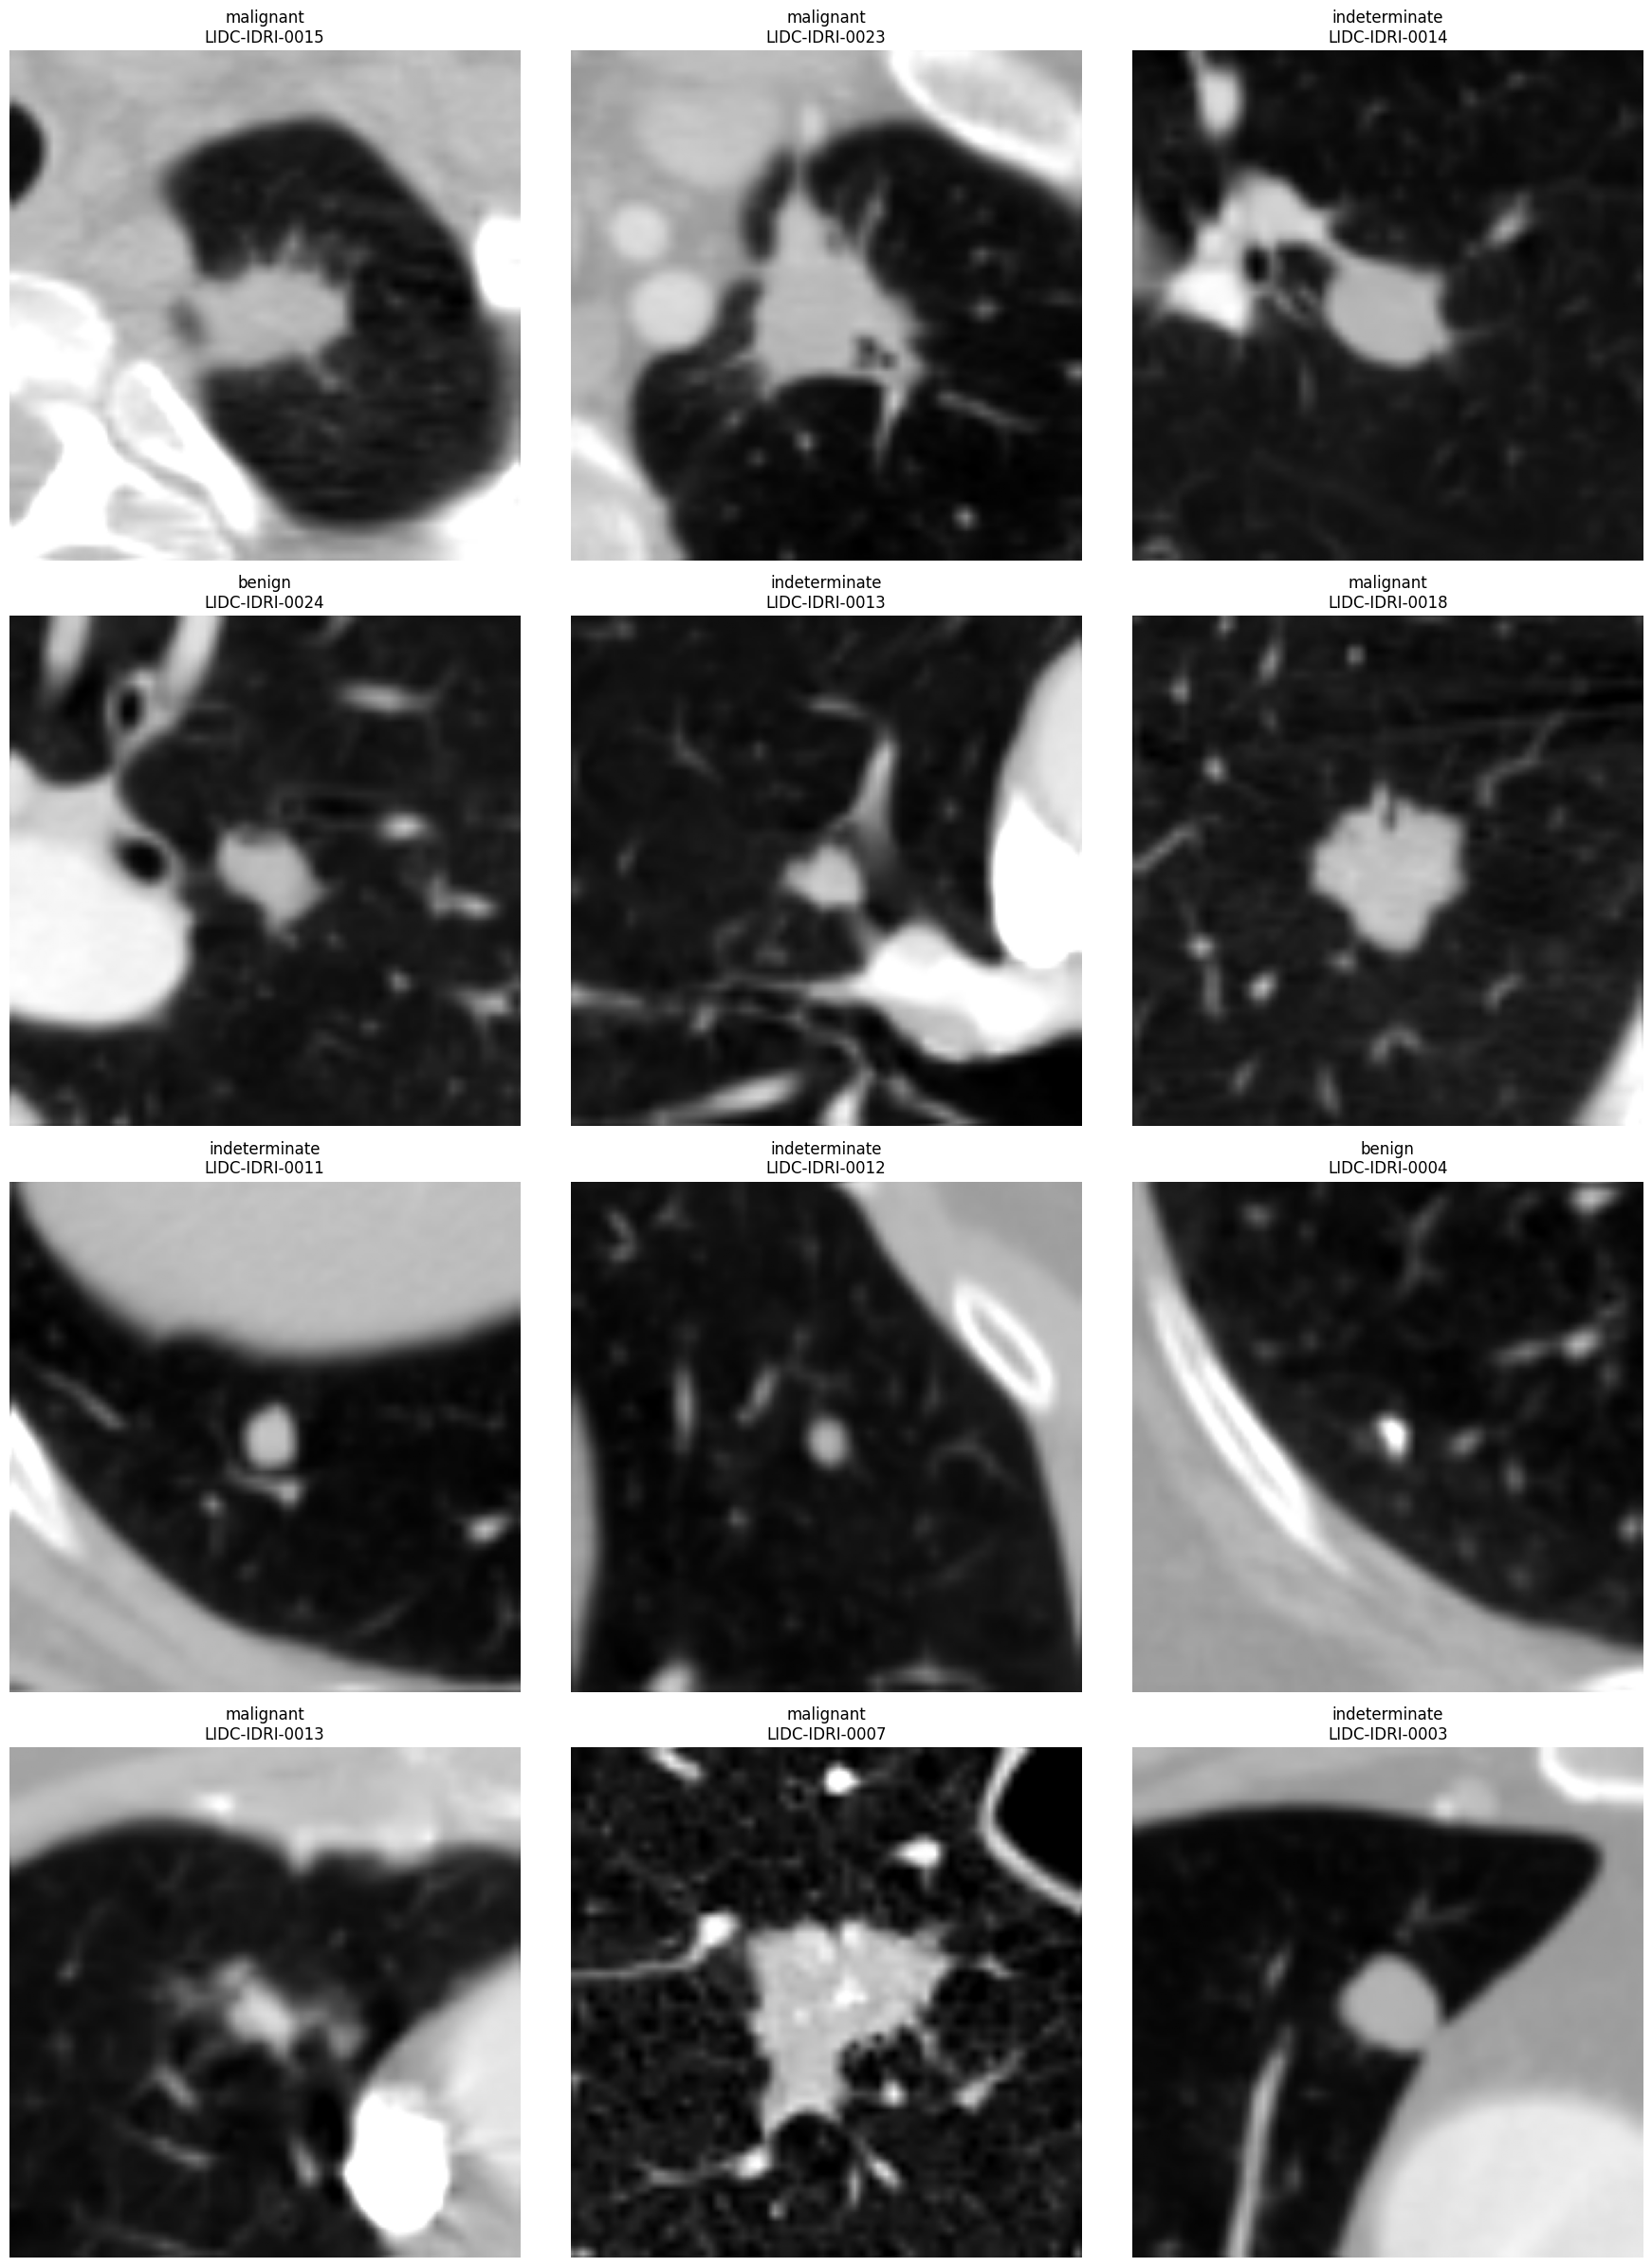

In [7]:
#@title 7. Optional: inspect sample images
sample_path = Path(df.iloc[0]["image_path"])
sample_img = np.load(sample_path)

print("Path :", sample_path)
print("Shape:", sample_img.shape)
print("Dtype:", sample_img.dtype)
print("Min  :", sample_img.min())
print("Max  :", sample_img.max())

def show_samples(df, n=12):
    n = min(n, len(df))
    sample_df = df.sample(n=n, random_state=SEED)

    cols = 3
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image_path = Path(row["image_path"])

        print(
            image_path,
            int(row["label"]),
            row["patient_id"]
        )

        # Preprocessing saves patches as NumPy arrays
        if image_path.suffix.lower() == ".npy":
            img = np.load(image_path)

        # Optional compatibility with ordinary image files
        else:
            img = np.asarray(Image.open(image_path).convert("L"))

        # Defensive handling in case an array has singleton dimensions
        img = np.squeeze(img)

        if img.ndim != 2:
            raise ValueError(
                f"Expected a 2D grayscale patch, "
                f"but got shape {img.shape} from {image_path}"
            )

        ax.imshow(img, cmap="gray")
        ax.set_title(
            f'{CLASS_NAMES[int(row["label"])]}\n'
            f'{row["patient_id"]}'
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(df)


#show_samples(df)


In [8]:
#@title 8. Dataset and training augmentations
# Preprocessing already performed HU clipping/rescaling and 224x224 extraction.
# Canonical preprocessing patches are .npy arrays, normally float32 in [0,1].
# Training-only augmentation follows the plan exactly:
# horizontal/vertical flips, ±15° rotation, ±10% translation.
# No elastic deformation and no intensity jitter.

def load_patch_gray01(image_path):
    """Load a preprocessing patch and return a 2D float32 array in [0,1]."""
    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(f"Patch not found: {image_path}")

    if image_path.suffix.lower() == '.npy':
        image = np.load(image_path, allow_pickle=False)
        image = np.asarray(image, dtype=np.float32)
    else:
        # Compatibility only; the canonical preprocessing output is .npy.
        with Image.open(image_path) as im:
            image = np.asarray(im.convert('L'), dtype=np.float32) / 255.0

    image = np.squeeze(image)
    if image.ndim != 2:
        raise ValueError(f"Expected a 2D grayscale patch, got shape={image.shape} from {image_path}")
    if not np.isfinite(image).all():
        raise ValueError(f"Patch contains NaN/Inf values: {image_path}")

    # Canonical preprocessing data should already be [0,1].  Keep a defensive
    # compatibility path for ordinary 8-bit images/arrays without re-windowing CT.
    vmin, vmax = float(image.min()), float(image.max())
    if vmin < -1e-6 or vmax > 1.0 + 1e-6:
        if vmin >= 0.0 and vmax <= 255.0:
            image = image / 255.0
        else:
            raise ValueError(
                f"Unexpected patch range [{vmin:.4f}, {vmax:.4f}] in {image_path}; "
                "expected preprocessing output scaled to [0,1]."
            )
    return np.clip(image, 0.0, 1.0).astype(np.float32)


def gray01_to_pil(gray01):
    gray01 = np.asarray(gray01, dtype=np.float32)
    u8 = np.rint(np.clip(gray01, 0.0, 1.0) * 255.0).astype(np.uint8)
    return Image.fromarray(u8, mode='L')


train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomAffine(degrees=15, translate=(0.10, 0.10)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
base_transform = eval_transform  # compatibility alias for XAI helpers


class LIDCPatchDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(row['image_path'])
        gray01 = load_patch_gray01(image_path)
        pil_image = gray01_to_pil(gray01)
        x = self.transform(pil_image) if self.transform is not None else transforms.ToTensor()(pil_image)

        item = {
            'image': x,
            'label': torch.tensor(int(row['label']), dtype=torch.long),
            'patient_id': str(row['patient_id']),
            'image_path': str(image_path),
            'nodule_id': str(row['nodule_id']),
            'V': torch.tensor(float(row['V']), dtype=torch.float32),
        }
        if 'mask_path' in row.index and pd.notna(row['mask_path']):
            item['mask_path'] = str(row['mask_path'])
        return item


In [9]:
#@title 9. Consume authoritative outer folds; create deterministic patient-stratified validation split
# Outer test membership is NEVER regenerated here. It comes only from fold_assignments.csv.
# Validation is selected at patient level from the remaining four folds with a deterministic
# stratified split. Final data must support this; no random fallback is allowed.

def dominant_patient_label(frame):
    def _mode(s):
        vc=s.value_counts()
        return int(sorted(vc[vc == vc.max()].index.tolist())[0])
    return frame.groupby('patient_id')['label'].agg(_mode)

def split_train_val_patients(trainval_df, fraction=0.10, seed=42):
    patient_labels = dominant_patient_label(trainval_df)
    pids = patient_labels.index.to_numpy()
    y = patient_labels.to_numpy()
    n_val = max(NUM_CLASSES, int(round(len(pids) * fraction)))
    n_val = min(n_val, len(pids)-NUM_CLASSES)
    counts = Counter(y)
    if len(counts) != NUM_CLASSES or min(counts.values()) < 2 or n_val < NUM_CLASSES:
        raise RuntimeError(
            'Patient-stratified validation is not feasible for this dataset. '
            'Do not fall back to a random split; fix the dataset/pilot configuration.'
        )
    sss = StratifiedShuffleSplit(n_splits=1, test_size=n_val, random_state=seed)
    tr_i, va_i = next(sss.split(pids, y))
    train_patients, val_patients = set(pids[tr_i]), set(pids[va_i])
    train = trainval_df[trainval_df.patient_id.isin(train_patients)].copy()
    val = trainval_df[trainval_df.patient_id.isin(val_patients)].copy()
    return train, val

folds=[]; manifest=[]
for test_fold in range(1,6):
    test = df[df.fold == test_fold].copy()
    trainval = df[df.fold != test_fold].copy()
    train, val = split_train_val_patients(trainval, 0.10, SEED + test_fold)

    A,B,C=set(train.patient_id),set(val.patient_id),set(test.patient_id)
    assert A.isdisjoint(B) and A.isdisjoint(C) and B.isdisjoint(C), 'Patient leakage detected'
    assert set(test.patient_id) == set(fold_df.loc[fold_df.fold==test_fold,'patient_id']) & set(df.patient_id)

    fold_dir=SPLIT_ROOT/f'fold_{test_fold}'
    train.to_csv(fold_dir/'train.csv',index=False)
    val.to_csv(fold_dir/'validation.csv',index=False)
    test.to_csv(fold_dir/'test.csv',index=False)

    folds.append({'fold':test_fold,'train':train.reset_index(drop=True),
                  'val':val.reset_index(drop=True),'test':test.reset_index(drop=True)})
    for name,frame in [('train',train),('validation',val),('test',test)]:
        manifest.append({
            'fold':test_fold,'split':name,'patches':len(frame),'patients':frame.patient_id.nunique(),
            'benign':int((frame.label==0).sum()),'indeterminate':int((frame.label==1).sum()),
            'malignant':int((frame.label==2).sum()),'validation_method':'patient-stratified',
            'fold_assignments_sha256':actual_fold_sha256
        })

manifest_df=pd.DataFrame(manifest)
manifest_df.to_csv(SPLIT_ROOT/'all_folds_summary.csv',index=False)
display(manifest_df)


,fold,split,patches,patients,benign,indeterminate,malignant,validation_method,fold_assignments_sha256
0,1,train,40,16,4,29,7,patient-stratified,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...
1,1,validation,6,3,0,4,2,patient-stratified,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...
2,1,test,2,2,1,0,1,patient-stratified,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...
3,2,train,26,13,4,17,5,patient-stratified,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...
4,2,validation,3,3,0,2,1,patient-stratified,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...
5,2,test,19,5,1,14,4,patient-stratified,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...
6,3,train,33,14,5,23,5,patient-stratified,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...
7,3,validation,9,3,0,5,4,patient-stratified,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...
8,3,test,6,4,0,5,1,patient-stratified,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...
9,4,train,34,13,4,22,8,patient-stratified,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...


In [10]:
#@title 10. DataLoader construction
def make_loaders(train_df,val_df,test_df):
    kwargs=dict(batch_size=BATCH_SIZE,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
    return (DataLoader(LIDCPatchDataset(train_df,train_transform),shuffle=True,**kwargs),
            DataLoader(LIDCPatchDataset(val_df,eval_transform),shuffle=False,**kwargs),
            DataLoader(LIDCPatchDataset(test_df,eval_transform),shuffle=False,**kwargs))


In [11]:
#@title 11. B1 ResNet50 with dropout before the final classifier
class ResNet50MCDropout(nn.Module):
    def __init__(self, num_classes=3, dropout_p=0.5, pretrained=True):
        super().__init__()

        weights = ResNet50_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet50(weights=weights)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def enable_dropout(self):
        # Enable dropout layers while preserving BatchNorm evaluation behavior.
        for module in self.modules():
            if isinstance(module, nn.Dropout):
                module.train()

model = ResNet50MCDropout(
    num_classes=NUM_CLASSES,
    dropout_p=DROPOUT_P,
    pretrained=True
).to(DEVICE)

print(model.backbone.fc)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 89.9MB/s]


Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=3, bias=True)
)


In [12]:
#@title 12. Required evaluation metrics

EPS=1e-12

def multiclass_brier_score(y_true,probs):
    oh=np.eye(NUM_CLASSES)[np.asarray(y_true,dtype=int)]
    return float(np.mean(np.sum((np.asarray(probs)-oh)**2,axis=1)))

def expected_calibration_error(y_true,probs,n_bins=15):
    y_true=np.asarray(y_true); probs=np.asarray(probs)
    conf=probs.max(1); pred=probs.argmax(1); correct=(pred==y_true).astype(float)
    edges=np.linspace(0,1,n_bins+1); ece=0.0
    for i,(lo,hi) in enumerate(zip(edges[:-1],edges[1:])):
        m=(conf>=lo)&(conf<=hi) if i==0 else (conf>lo)&(conf<=hi)
        if m.any(): ece+=m.mean()*abs(correct[m].mean()-conf[m].mean())
    return float(ece)

def safe_macro_auroc(y_true, probs):
    """T7-safe macro OvR AUROC shared by B1, B3, and C1."""
    y = np.asarray(y_true, dtype=int)
    p = np.asarray(probs, dtype=float)
    yb = label_binarize(y, classes=[0, 1, 2])

    aucs = []
    for k in range(3):
        # AUROC is undefined if this one-vs-rest target has only one value.
        if len(np.unique(yb[:, k])) < 2:
            continue
        aucs.append(float(roc_auc_score(yb[:, k], p[:, k])))

    return float(np.mean(aucs)) if aucs else np.nan

def compute_classification_metrics(y_true,probs):
    y=np.asarray(y_true,dtype=int); p=np.asarray(probs,dtype=float); pred=p.argmax(1)
    return {'accuracy':float(accuracy_score(y,pred)),
            'macro_f1':float(f1_score(y,pred,average='macro',zero_division=0)),
            'auroc_ovr_macro':safe_macro_auroc(y,p),
            'brier_score':multiclass_brier_score(y,p),
            'ece_15':expected_calibration_error(y,p,ECE_BINS),
            'nll':float(-np.mean(np.log(np.clip(p[np.arange(len(y)),y],EPS,1.0))))}

In [13]:
#@title 13. Training and validation utilities
def standard_forward(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            total_loss += loss.item() * images.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())
    probabilities = np.concatenate(all_probs, axis=0)
    labels = np.asarray(all_labels)
    metrics = compute_classification_metrics(labels, probabilities)
    metrics["loss"] = float(total_loss / len(loader.dataset))
    return metrics, labels, probabilities

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss=0.0; correct=0; total=0
    for batch in loader:
        images=batch["image"].to(DEVICE, non_blocking=True)
        labels=batch["label"].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits=model(images)
        loss=criterion(logits,labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item()*images.size(0)
        correct += int((logits.argmax(1)==labels).sum().item())
        total += int(labels.numel())
    return running_loss/len(loader.dataset), correct/max(total,1)


In [14]:
#@title 14. Train one fold with AdamW, cosine annealing, and Brier-based early stopping
def train_fold(train_loader, val_loader, fold_number, run_dir):
    model = ResNet50MCDropout(
        num_classes=NUM_CLASSES,
        dropout_p=DROPOUT_P,
        pretrained=True
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        betas=(0.9, 0.999),
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=MAX_EPOCHS,
        eta_min=MIN_LEARNING_RATE
    )

    history = []
    best_state = None
    best_val_brier = float("inf")
    epochs_without_improvement = 0

    run_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics, _, _ = standard_forward(model, val_loader, criterion)
        scheduler.step()

        record = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "train_accuracy": float(train_accuracy),
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }
        history.append(record)

        print(
            f"Fold {fold_number} | Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_accuracy:.3f} | "
            f"val_brier={val_metrics['brier_score']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["brier_score"] < best_val_brier:
            best_val_brier = val_metrics["brier_score"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0

            torch.save(
                {
                    "fold": fold_number,
                    "epoch": epoch,
                    "model_state_dict": best_state,
                    "best_val_brier": best_val_brier,
                    "config": {
                        "backbone": "ResNet50",
                        "dropout_p": DROPOUT_P,
                        "mc_t": MC_T,
                        "seed": SEED
                    }
                },
                CHECKPOINT_ROOT / f'fold_{fold_number}' / 'best_model.pt'
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)
    torch.save({'fold': fold_number, 'model_state_dict': model.state_dict()}, CHECKPOINT_ROOT / f'fold_{fold_number}' / 'final_model.pt')
    pd.DataFrame(history).to_csv(LOG_ROOT / f"fold_{fold_number}_history.csv", index=False)
    return model, pd.DataFrame(history)


In [15]:
#@title 15. MC Dropout inference (T=30) with BatchNorm frozen
def enable_mc_dropout(model):
    # First put the complete model in eval mode: BatchNorm and all deterministic layers freeze.
    model.eval()
    # Then re-enable ONLY dropout modules.
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

@torch.no_grad()
def mc_dropout_predict(model,loader,T=30):
    enable_mc_dropout(model)
    passes=[]; labels=None; metadata=None
    for t in tqdm(range(T),desc=f'MC Dropout T={T}',leave=False):
        pp=[]; yy=[]; mm=[]
        for batch in loader:
            x=batch['image'].to(DEVICE,non_blocking=True)
            probs=torch.softmax(model(x),1).cpu().numpy(); pp.append(probs)
            if t==0:
                yy.extend(batch['label'].numpy().tolist())
                for j in range(len(batch['label'])):
                    mm.append({
                        'patient_id':str(batch['patient_id'][j]),
                        'nodule_id':str(batch['nodule_id'][j]),
                        'image_path':str(batch['image_path'][j]),
                        'V':float(batch['V'][j].item())
                    })
        passes.append(np.concatenate(pp,0))
        if t==0: labels=np.asarray(yy); metadata=mm
    mc=np.stack(passes,0); mean=mc.mean(0)
    clipped=np.clip(mean,EPS,1.0)
    pred_ent=-np.sum(clipped*np.log(clipped),axis=1)
    mc_clip=np.clip(mc,EPS,1.0)
    exp_ent=-np.mean(np.sum(mc_clip*np.log(mc_clip),axis=2),axis=0)
    mi=pred_ent-exp_ent
    prob_var=mc.var(0).mean(1)
    plabel=mc.argmax(2); vr=[]
    for i in range(plabel.shape[1]):
        c=np.bincount(plabel[:,i],minlength=NUM_CLASSES); vr.append(1-c.max()/T)
    return {'mc_probs':mc,'mean_probabilities':mean,'labels':labels,'metadata':metadata,
            'predictive_entropy':pred_ent,'mutual_information':mi,
            'mean_probability_variance':prob_var,'variation_ratio':np.asarray(vr)}


In [16]:
#@title 16. Save MC predictions and core metrics
def save_mc_results(mc_results,fold_number):
    p=mc_results['mean_probabilities']; y=mc_results['labels']
    metrics=compute_classification_metrics(y,p)
    metrics.update({'mean_predictive_entropy':float(mc_results['predictive_entropy'].mean()),
                    'mean_mutual_information':float(mc_results['mutual_information'].mean()),
                    'mean_probability_variance':float(mc_results['mean_probability_variance'].mean()),
                    'mean_variation_ratio':float(mc_results['variation_ratio'].mean())})
    rows=[]
    for i,m in enumerate(mc_results['metadata']):
        rows.append({'fold':fold_number,'patient_id':m['patient_id'],'nodule_id':m['nodule_id'],'image_path':m['image_path'],'V':float(m['V']),
                     'true_label':int(y[i]),'predicted_label':int(p[i].argmax()),
                     'p_benign':float(p[i,0]),'p_indeterminate':float(p[i,1]),'p_malignant':float(p[i,2]),
                     'u':float(mc_results['predictive_entropy'][i]),
                     'predictive_entropy':float(mc_results['predictive_entropy'][i]),
                     'mutual_information':float(mc_results['mutual_information'][i]),
                     'mean_probability_variance':float(mc_results['mean_probability_variance'][i]),
                     'variation_ratio':float(mc_results['variation_ratio'][i])})
    pred_df=pd.DataFrame(rows)
    pred_df.to_csv(MC_PRED_ROOT/f'fold_{fold_number}_predictions.csv',index=False)
    np.save(MC_PRED_ROOT/f'fold_{fold_number}_probabilities.npy', mc_results['mc_probs'])
    pd.DataFrame({'predictive_entropy': mc_results['predictive_entropy']}).to_csv(MC_PRED_ROOT/f'fold_{fold_number}_entropy.csv', index=False)
    return metrics,pred_df


In [17]:
#@title 17. Verifier-aligned full 1...N predictive-entropy rejection curve + random lower bound
# T6 FIX: Primary rejection AUC now uses every possible retained count r=1,...,N,
# matching verify_edl_haal.py and the recent C1 implementation.
# Lowest-uncertainty samples are retained first.

def rejection_curve(labels, probs, uncertainty):
    y = np.asarray(labels)
    probs = np.asarray(probs)
    u = np.asarray(uncertainty)

    n = len(y)
    order = np.argsort(u)  # low uncertainty retained first
    correct = (probs.argmax(1) == y)[order].astype(np.float64)
    r = np.arange(1, n + 1)

    return pd.DataFrame({
        "coverage": r / n,
        "n_kept": r,  # preserve B1's existing output-column name
        "accuracy": np.cumsum(correct) / r
    })

def random_rejection_curve(labels, probs, repeats=50, seed=42):
    """Random-rejection lower bound evaluated on the same full r=1,...,N coverage axis."""
    y = np.asarray(labels)
    pred = np.asarray(probs).argmax(1)
    n = len(y)
    r = np.arange(1, n + 1)
    rng = np.random.RandomState(seed)

    arr = []
    for _ in range(repeats):
        order = rng.permutation(n)
        correct = (pred[order] == y[order]).astype(np.float64)
        arr.append(np.cumsum(correct) / r)

    arr = np.asarray(arr)
    return pd.DataFrame({
        "coverage": r / n,
        "n_kept": r,
        "accuracy": arr.mean(0),
        "accuracy_sd": arr.std(0)
    })

def save_rejection_curves(mc_results, fold):
    a = rejection_curve(
        mc_results["labels"],
        mc_results["mean_probabilities"],
        mc_results["predictive_entropy"]
    )
    r = random_rejection_curve(
        mc_results["labels"],
        mc_results["mean_probabilities"],
        repeats=50,
        seed=SEED + fold
    )

    a.to_csv(UNC_METRICS_ROOT / f"fold_{fold}_rejection_entropy.csv", index=False)
    r.to_csv(UNC_METRICS_ROOT / f"fold_{fold}_rejection_random.csv", index=False)

    plt.figure(figsize=(7, 5))
    plt.plot(a.coverage, a.accuracy, label="MC predictive entropy")
    plt.plot(r.coverage, r.accuracy, label="Random")
    plt.xlabel("Coverage")
    plt.ylabel("Accuracy")
    plt.title(f"Fold {fold} rejection curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(REJ_PLOT_ROOT / f"fold_{fold}_rejection.png", dpi=160)
    plt.close()

    return {
        "rejection_auc_entropy": float(np.trapezoid(a.accuracy, a.coverage)),
        "rejection_auc_random": float(np.trapezoid(r.accuracy, r.coverage))
    }


In [19]:
#@title 18. Grad-CAM for ResNet50 (no external Grad-CAM package required)
class GradCAM:
    def __init__(self,model,target_layer):
        self.model=model; self.activations=None; self.gradients=None
        self.h1=target_layer.register_forward_hook(lambda m,i,o:setattr(self,'activations',o))
        self.h2=target_layer.register_full_backward_hook(lambda m,gi,go:setattr(self,'gradients',go[0]))
    def generate(self,x,class_index=None):
        self.model.eval(); logits=self.model(x)
        if class_index is None: class_index=int(logits.argmax(1).item())
        self.model.zero_grad(set_to_none=True); logits[:,class_index].sum().backward()
        w=self.gradients.mean((2,3),keepdim=True); cam=F.relu((w*self.activations).sum(1,keepdim=True))
        cam=F.interpolate(cam,size=(IMG_SIZE,IMG_SIZE),mode='bilinear',align_corners=False)[0,0].detach().cpu().numpy()
        cam-=cam.min(); cam=cam/(cam.max()+1e-12)
        return cam,class_index
    def close(self): self.h1.remove(); self.h2.remove()

def save_gradcams(model,test_df,fold,max_examples=30):
    out=GRADCAM_ROOT/f'fold_{fold}'; out.mkdir(parents=True,exist_ok=True)
    ds=LIDCPatchDataset(test_df,base_transform); gc=GradCAM(model,model.backbone.layer4); rows=[]
    try:
        for i in range(min(len(ds),max_examples)):
            s=ds[i]; x=s['image'].unsqueeze(0).to(DEVICE); cam,pred=gc.generate(x)
            gray=load_patch_gray01(s['image_path'])
            stem=Path(s['image_path']).stem; npy=out/f'{stem}_gradcam.npy'; png=out/f'{stem}_gradcam.png'; np.save(npy,cam)
            plt.figure(figsize=(5,5)); plt.imshow(gray,cmap='gray'); plt.imshow(cam,cmap='jet',alpha=.45); plt.axis('off')
            plt.title(f"true={CLASS_NAMES[int(s['label'])]} pred={CLASS_NAMES[pred]}"); plt.tight_layout(); plt.savefig(png,dpi=160,bbox_inches='tight'); plt.close()
            rows.append({'fold':fold,'image_path':s['image_path'],'patient_id':s['patient_id'],'true_label':int(s['label']),
                         'predicted_label':pred,'gradcam_png':str(png),'gradcam_npy':str(npy)})
    finally: gc.close()
    pd.DataFrame(rows).to_csv(GRADCAM_ROOT/f'fold_{fold}_gradcam_manifest.csv',index=False)


In [20]:
#@title 19. Efficiency: parameters, FLOPs, full T=30 latency
def efficiency_metrics(model,test_loader):
    params=sum(p.numel() for p in model.parameters())
    dummy=torch.randn(1,3,IMG_SIZE,IMG_SIZE,device=DEVICE)
    try: flops,_=profile(model,inputs=(dummy,),verbose=False)
    except Exception: flops=np.nan
    single=DataLoader(test_loader.dataset,batch_size=1,shuffle=False,num_workers=0)
    times=[]; enable_mc_dropout(model)
    for j,b in enumerate(single):
        if j>=min(50,len(single.dataset)): break
        x=b['image'].to(DEVICE)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t0=time.perf_counter()
        with torch.no_grad():
            for _ in range(MC_T): _=model(x)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        times.append((time.perf_counter()-t0)*1000)
    return {'parameter_count':int(params),'single_pass_flops':float(flops) if np.isfinite(flops) else np.nan,
            'mc_dropout_T30_latency_ms_per_image':float(np.mean(times)) if times else np.nan}

In [21]:
#@title 20. DataLoader sanity check before the 5-fold run
# `folds` is created in Cell 9. There is no `fold_infos` variable in this notebook.
assert len(folds) == 5, f"Expected 5 folds, found {len(folds)}"

sanity_info = folds[0]
train_loader, val_loader, test_loader = make_loaders(
    sanity_info['train'],
    sanity_info['val'],
    sanity_info['test']
)

batch = next(iter(train_loader))
print('Image batch shape :', batch['image'].shape)
print('Image dtype       :', batch['image'].dtype)
print('Label shape       :', batch['label'].shape)
print('Labels            :', batch['label'][:10])
print('Image min         :', batch['image'].min().item())
print('Image max         :', batch['image'].max().item())

assert batch['image'].ndim == 4
assert batch['image'].shape[1] == 3
assert batch['image'].shape[2:] == (IMG_SIZE, IMG_SIZE)
assert batch['label'].dtype == torch.long
assert torch.isfinite(batch['image']).all()

print('\n✓ DataLoader sanity check PASSED')


Image batch shape : torch.Size([32, 3, 224, 224])
Image dtype       : torch.float32
Label shape       : torch.Size([32])
Labels            : tensor([1, 1, 1, 2, 1, 2, 2, 1, 1, 0])
Image min         : -2.1179039478302
Image max         : 2.640000104904175

✓ DataLoader sanity check PASSED


In [22]:
#@title 20. Run all 5 folds and save artifacts into folder.rtf subfolders
RUN_ALL_FOLDS=True
all_fold_metrics=[]

def save_deterministic_predictions(model, loader, fold):
    criterion=nn.CrossEntropyLoss()
    metrics,y,p=standard_forward(model,loader,criterion)
    rows=[]
    offset=0
    for batch in loader:
        n=len(batch['label'])
        for j in range(n):
            i=offset+j
            rows.append({'fold':fold,'patient_id':batch['patient_id'][j],'nodule_id':batch['nodule_id'][j],'image_path':batch['image_path'][j],
                         'V':float(batch['V'][j].item()),
                         'true_label':int(y[i]),'predicted_label':int(p[i].argmax()),
                         'p_benign':float(p[i,0]),'p_indeterminate':float(p[i,1]),'p_malignant':float(p[i,2])})
        offset += n
    pd.DataFrame(rows).to_csv(DET_PRED_ROOT/f'fold_{fold}_predictions.csv',index=False)
    return metrics

if RUN_ALL_FOLDS:
    for info in folds:
        fold=info['fold']; print('\n'+'='*72); print('B1 FOLD',fold); print('='*72)
        seed_everything(SEED)  # same documented seed for reproducible fold training
        train_loader,val_loader,test_loader=make_loaders(info['train'],info['val'],info['test'])
        model,history=train_fold(train_loader,val_loader,fold,CHECKPOINT_ROOT)

        det_metrics=save_deterministic_predictions(model,test_loader,fold)
        mc=mc_dropout_predict(model,test_loader,T=MC_T)
        metrics,pred_df=save_mc_results(mc,fold)
        metrics.update(save_rejection_curves(mc,fold))
        eff=efficiency_metrics(model,test_loader); metrics.update(eff)
        save_gradcams(model,info['test'],fold,max_examples=30)

        metrics.update({'fold':fold,'test_patches':len(info['test']),'test_patients':info['test'].patient_id.nunique(),
                        'xai_quantitative_status':'Grad-CAM exported; quantitative contour metrics optional',
                        'fold_assignments_sha256':actual_fold_sha256,'formal_run':FORMAL_RUN,'device':str(DEVICE)})

        # Required metric families in their specified subfolders.
        pd.DataFrame([{'fold':fold,'macro_f1':metrics['macro_f1'],'auroc_ovr_macro':metrics['auroc_ovr_macro'],
                       'accuracy':metrics['accuracy']}]).to_csv(CLASS_METRICS_ROOT/f'fold_{fold}_classification.csv',index=False)
        pd.DataFrame([{'fold':fold,'brier_score':metrics['brier_score'],'ece_15':metrics['ece_15'],
                       'nll':metrics['nll']}]).to_csv(CAL_METRICS_ROOT/f'fold_{fold}_calibration.csv',index=False)
        pd.DataFrame([{'fold':fold,'mean_predictive_entropy':metrics['mean_predictive_entropy'],
                       'mean_mutual_information':metrics['mean_mutual_information'],
                       'mean_probability_variance':metrics['mean_probability_variance'],
                       'mean_variation_ratio':metrics['mean_variation_ratio'],
                       'rejection_auc_entropy':metrics['rejection_auc_entropy'],
                       'rejection_auc_random':metrics['rejection_auc_random']}]).to_csv(
                           UNC_METRICS_ROOT/f'fold_{fold}_uncertainty.csv',index=False)
        pd.DataFrame([{'fold':fold,**eff}]).to_csv(EFF_METRICS_ROOT/f'fold_{fold}_efficiency.csv',index=False)

        all_fold_metrics.append(metrics)
        del model; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    results_df=pd.DataFrame(all_fold_metrics)
    results_df.to_csv(CLASS_METRICS_ROOT/'fold_metrics.csv',index=False)

    # Folder.rtf canonical aggregate files.
    results_df[['fold','macro_f1','auroc_ovr_macro','accuracy']].to_csv(CLASS_METRICS_ROOT/'overall_metrics.csv',index=False)
    results_df[['fold','brier_score']].to_csv(CAL_METRICS_ROOT/'brier_scores.csv',index=False)
    results_df[['fold','ece_15']].to_csv(CAL_METRICS_ROOT/'ece_scores.csv',index=False)
    results_df[['fold','nll']].to_csv(CAL_METRICS_ROOT/'nll_scores.csv',index=False)
    results_df[['fold','mean_predictive_entropy','mean_mutual_information','mean_probability_variance']].to_csv(
        UNC_METRICS_ROOT/'entropy_summary.csv',index=False)
    results_df[['fold','mean_variation_ratio']].to_csv(UNC_METRICS_ROOT/'variation_ratio.csv',index=False)
    results_df[['fold','rejection_auc_entropy','rejection_auc_random']].to_csv(UNC_METRICS_ROOT/'rejection_curves.csv',index=False)
    results_df[['fold','mc_dropout_T30_latency_ms_per_image']].to_csv(EFF_METRICS_ROOT/'latency.csv',index=False)
    results_df[['fold','parameter_count','single_pass_flops']].to_csv(EFF_METRICS_ROOT/'parameter_count.csv',index=False)
    display(results_df)



B1 FOLD 1
Fold 1 | Epoch 01 | train_loss=1.1079 | train_acc=0.400 | val_brier=0.6668 | val_macro_f1=0.1429
Fold 1 | Epoch 02 | train_loss=1.0401 | train_acc=0.575 | val_brier=0.6201 | val_macro_f1=0.4000
Fold 1 | Epoch 03 | train_loss=0.9894 | train_acc=0.775 | val_brier=0.6139 | val_macro_f1=0.4000
Fold 1 | Epoch 04 | train_loss=0.9478 | train_acc=0.700 | val_brier=0.6071 | val_macro_f1=0.4000
Fold 1 | Epoch 05 | train_loss=0.9102 | train_acc=0.750 | val_brier=0.5882 | val_macro_f1=0.4000
Fold 1 | Epoch 06 | train_loss=0.8259 | train_acc=0.700 | val_brier=0.5613 | val_macro_f1=0.4000
Fold 1 | Epoch 07 | train_loss=0.8244 | train_acc=0.725 | val_brier=0.5425 | val_macro_f1=0.4000
Fold 1 | Epoch 08 | train_loss=0.7706 | train_acc=0.725 | val_brier=0.5513 | val_macro_f1=0.4000
Fold 1 | Epoch 09 | train_loss=0.7540 | train_acc=0.725 | val_brier=0.5436 | val_macro_f1=0.4000
Fold 1 | Epoch 10 | train_loss=0.6840 | train_acc=0.725 | val_brier=0.5279 | val_macro_f1=0.4000
Fold 1 | Epoch 11 |

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B1 FOLD 2
Fold 2 | Epoch 01 | train_loss=1.0990 | train_acc=0.462 | val_brier=0.6805 | val_macro_f1=0.2500
Fold 2 | Epoch 02 | train_loss=1.0966 | train_acc=0.385 | val_brier=0.6531 | val_macro_f1=0.4000
Fold 2 | Epoch 03 | train_loss=1.0997 | train_acc=0.308 | val_brier=0.6447 | val_macro_f1=0.4000
Fold 2 | Epoch 04 | train_loss=1.0641 | train_acc=0.462 | val_brier=0.6375 | val_macro_f1=0.4000
Fold 2 | Epoch 05 | train_loss=0.9928 | train_acc=0.654 | val_brier=0.6219 | val_macro_f1=0.4000
Fold 2 | Epoch 06 | train_loss=0.9946 | train_acc=0.615 | val_brier=0.6034 | val_macro_f1=0.4000
Fold 2 | Epoch 07 | train_loss=0.9278 | train_acc=0.654 | val_brier=0.5851 | val_macro_f1=0.4000
Fold 2 | Epoch 08 | train_loss=0.9481 | train_acc=0.654 | val_brier=0.5690 | val_macro_f1=0.4000
Fold 2 | Epoch 09 | train_loss=0.9341 | train_acc=0.654 | val_brier=0.5568 | val_macro_f1=0.4000
Fold 2 | Epoch 10 | train_loss=0.8879 | train_acc=0.654 | val_brier=0.5556 | val_macro_f1=0.4000
Fold 2 | Epoch 11 |

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B1 FOLD 3
Fold 3 | Epoch 01 | train_loss=1.1040 | train_acc=0.424 | val_brier=0.6811 | val_macro_f1=0.3077
Fold 3 | Epoch 02 | train_loss=1.0536 | train_acc=0.545 | val_brier=0.6630 | val_macro_f1=0.2222
Fold 3 | Epoch 03 | train_loss=1.0328 | train_acc=0.606 | val_brier=0.6677 | val_macro_f1=0.2778
Fold 3 | Epoch 04 | train_loss=0.9584 | train_acc=0.697 | val_brier=0.6621 | val_macro_f1=0.2778
Fold 3 | Epoch 05 | train_loss=0.9929 | train_acc=0.697 | val_brier=0.6632 | val_macro_f1=0.3077
Fold 3 | Epoch 06 | train_loss=0.8837 | train_acc=0.697 | val_brier=0.6583 | val_macro_f1=0.3077
Fold 3 | Epoch 07 | train_loss=0.8949 | train_acc=0.667 | val_brier=0.6551 | val_macro_f1=0.3535
Fold 3 | Epoch 08 | train_loss=0.8804 | train_acc=0.667 | val_brier=0.6527 | val_macro_f1=0.5000
Fold 3 | Epoch 09 | train_loss=0.8232 | train_acc=0.697 | val_brier=0.6508 | val_macro_f1=0.2500
Fold 3 | Epoch 10 | train_loss=0.8532 | train_acc=0.697 | val_brier=0.6440 | val_macro_f1=0.4156
Fold 3 | Epoch 11 |

...


B1 FOLD 4
Fold 4 | Epoch 01 | train_loss=1.1344 | train_acc=0.176 | val_brier=0.6268 | val_macro_f1=0.4000
Fold 4 | Epoch 02 | train_loss=1.0694 | train_acc=0.382 | val_brier=0.5998 | val_macro_f1=0.4000
Fold 4 | Epoch 03 | train_loss=1.0398 | train_acc=0.559 | val_brier=0.5891 | val_macro_f1=0.4000
Fold 4 | Epoch 04 | train_loss=0.9824 | train_acc=0.706 | val_brier=0.6238 | val_macro_f1=0.4000
Fold 4 | Epoch 05 | train_loss=0.9487 | train_acc=0.706 | val_brier=0.6259 | val_macro_f1=0.4000
Fold 4 | Epoch 06 | train_loss=0.9772 | train_acc=0.676 | val_brier=0.6450 | val_macro_f1=0.4000
Fold 4 | Epoch 07 | train_loss=0.9332 | train_acc=0.647 | val_brier=0.6463 | val_macro_f1=0.4000
Fold 4 | Epoch 08 | train_loss=0.9475 | train_acc=0.676 | val_brier=0.6343 | val_macro_f1=0.4000
Fold 4 | Epoch 09 | train_loss=0.8802 | train_acc=0.647 | val_brier=0.6318 | val_macro_f1=0.4000
Fold 4 | Epoch 10 | train_loss=0.8844 | train_acc=0.647 | val_brier=0.6279 | val_macro_f1=0.4000
Fold 4 | Epoch 11 |

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]


B1 FOLD 5
Fold 5 | Epoch 01 | train_loss=1.0985 | train_acc=0.438 | val_brier=0.6155 | val_macro_f1=0.2222
Fold 5 | Epoch 02 | train_loss=1.0962 | train_acc=0.312 | val_brier=0.5705 | val_macro_f1=0.4545
Fold 5 | Epoch 03 | train_loss=1.0261 | train_acc=0.656 | val_brier=0.5304 | val_macro_f1=0.4545
Fold 5 | Epoch 04 | train_loss=0.9964 | train_acc=0.625 | val_brier=0.5054 | val_macro_f1=0.4545
Fold 5 | Epoch 05 | train_loss=0.9987 | train_acc=0.656 | val_brier=0.4911 | val_macro_f1=0.4545
Fold 5 | Epoch 06 | train_loss=0.9497 | train_acc=0.688 | val_brier=0.4946 | val_macro_f1=0.4545
Fold 5 | Epoch 07 | train_loss=0.8656 | train_acc=0.719 | val_brier=0.4914 | val_macro_f1=0.4545
Fold 5 | Epoch 08 | train_loss=0.8601 | train_acc=0.719 | val_brier=0.4842 | val_macro_f1=0.4545
Fold 5 | Epoch 09 | train_loss=0.8184 | train_acc=0.719 | val_brier=0.4696 | val_macro_f1=0.4545
Fold 5 | Epoch 10 | train_loss=0.8907 | train_acc=0.719 | val_brier=0.4682 | val_macro_f1=0.4545
Fold 5 | Epoch 11 |

MC Dropout T=30:   0%|          | 0/30 [00:00<?, ?it/s]

,accuracy,macro_f1,auroc_ovr_macro,brier_score,ece_15,nll,mean_predictive_entropy,mean_mutual_information,mean_probability_variance,mean_variation_ratio,...,parameter_count,single_pass_flops,mc_dropout_T30_latency_ms_per_image,fold,test_patches,test_patients,xai_quantitative_status,fold_assignments_sha256,formal_run,device
0,0.000000,0.000000,0.500000,0.737755,0.428384,1.198059,1.067358,0.004412,0.000981,0.216667,...,23514179,4.131701e+09,243.505486,1,2,2,Grad-CAM exported; quantitative contour metric...,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...,True,cuda
1,0.736842,0.282828,0.579894,0.556512,0.290431,0.944484,1.067320,0.003605,0.000799,0.014035,...,23514179,4.131701e+09,230.433589,2,19,5,Grad-CAM exported; quantitative contour metric...,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...,True,cuda
2,0.833333,0.454545,0.100000,0.632832,0.468231,1.048374,1.095738,0.001367,0.000302,0.183333,...,23514179,4.131701e+09,224.573327,3,6,4,Grad-CAM exported; quantitative contour metric...,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...,True,cuda
3,0.727273,0.280702,0.088889,0.616782,0.336171,1.029348,1.086932,0.006222,0.001379,0.248485,...,23514179,4.131701e+09,273.372584,4,11,5,Grad-CAM exported; quantitative contour metric...,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...,True,cuda
4,0.500000,0.222222,0.261984,0.688630,0.414557,1.129850,0.925121,0.006274,0.001239,0.000000,...,23514179,4.131701e+09,258.421740,5,10,5,Grad-CAM exported; quantitative contour metric...,6579bbae4001911dbeb74213340e7846c3dcc2d03f915e...,True,cuda


In [23]:
#@title 21. Five-fold mean ± standard deviation + M2/report outputs
if RUN_ALL_FOLDS and len(all_fold_metrics):
    results_df=pd.DataFrame(all_fold_metrics)
    rows=[]
    for c in results_df.columns:
        if c=='fold' or not pd.api.types.is_numeric_dtype(results_df[c]): continue
        v=pd.to_numeric(results_df[c],errors='coerce')
        rows.append({'metric':c,'mean':float(v.mean()) if v.notna().any() else np.nan,
                     'std':float(v.std(ddof=1)) if v.notna().sum()>1 else np.nan,'n_valid_folds':int(v.notna().sum())})
    summary_df=pd.DataFrame(rows)
    summary_df.to_csv(REPORT_ROOT/'B1_results_summary.csv',index=False)

    f1mean=float(results_df['macro_f1'].mean())
    milestone={'M2_threshold_macro_f1':0.50,'observed_mean_macro_f1':f1mean,'passed':bool(f1mean>0.50),
               'formal_run':bool(PILOT_MAX_PATIENTS is None),
               'rule':'Professor M2: B1 should produce non-trivial Macro-F1 > 0.50; otherwise debug pipeline before proceeding.'}
    report={'experiment':'B1_ResNet50_MC_Dropout_T30','folds':5,
            'mean_plus_minus_std':{r['metric']:{'mean':r['mean'],'std':r['std']} for r in rows},
            'M2':milestone}
    with open(REPORT_ROOT/'B1_results_summary.json','w') as f: json.dump(report,f,indent=2)
    with open(REPORT_ROOT/'B1_experiment_notes.md','w') as f:
        f.write('# B1 experiment notes\n\n')
        f.write('Historical baseline: ImageNet ResNet50 + dropout p=0.5 + cross-entropy; MC Dropout T=30 at inference.\n\n')
        f.write('Outer folds are inherited from preprocessing; all train/validation/test partitions are patient-disjoint.\n\n')
        f.write(f"M2 Macro-F1 > 0.50 passed: {milestone['passed']} (mean={f1mean:.4f}).\n")
    display(summary_df); print(milestone)


,metric,mean,std,n_valid_folds
0,accuracy,5.594896e-01,0.335843,5
1,macro_f1,2.480595e-01,0.163640,5
2,auroc_ovr_macro,3.061534e-01,0.225923,5
3,brier_score,6.465022e-01,0.069409,5
4,ece_15,3.875549e-01,0.072419,5
5,nll,1.070023e+00,0.097283,5
6,mean_predictive_entropy,1.048494e+00,0.070072,5
7,mean_mutual_information,4.375906e-03,0.002041,5
8,mean_probability_variance,9.398873e-04,0.000421,5
9,mean_variation_ratio,1.325040e-01,0.116952,5


{'M2_threshold_macro_f1': 0.5, 'observed_mean_macro_f1': 0.24805954279638492, 'passed': False, 'formal_run': True, 'rule': 'Professor M2: B1 should produce non-trivial Macro-F1 > 0.50; otherwise debug pipeline before proceeding.'}


In [24]:
#@title 22. Reliability diagram helper (ECE)
def save_reliability_diagram(y_true,probs,fold):
    y=np.asarray(y_true); p=np.asarray(probs); conf=p.max(1); pred=p.argmax(1); correct=(pred==y).astype(float)
    edges=np.linspace(0,1,ECE_BINS+1); xs=[]; ys=[]
    for i,(lo,hi) in enumerate(zip(edges[:-1],edges[1:])):
        m=(conf>=lo)&(conf<=hi) if i==0 else (conf>lo)&(conf<=hi)
        if m.any(): xs.append(conf[m].mean()); ys.append(correct[m].mean())
    plt.figure(figsize=(6,6)); plt.plot([0,1],[0,1],'--',label='Perfect'); plt.plot(xs,ys,marker='o',label='B1 MC Dropout')
    plt.xlabel('Mean confidence'); plt.ylabel('Accuracy'); plt.title(f'Fold {fold} reliability'); plt.legend(); plt.tight_layout()
    plt.savefig(REL_PLOT_ROOT/f'fold_{fold}_reliability.png',dpi=160); plt.close()

print(folds)
# Generate from saved prediction CSVs without rerunning inference.
if RUN_ALL_FOLDS:
    for fold in range(1,6):
        pth=MC_PRED_ROOT/f'fold_{fold}_predictions.csv'
        if pth.exists():
            q=pd.read_csv(pth); probs=q[['p_benign','p_indeterminate','p_malignant']].values
            save_reliability_diagram(q.true_label.values,probs,fold)


[{'fold': 1, 'train':     array_index                nodule_id      patient_id  scan_db_id  \
0             7  LIDC-IDRI-0006_S17_N003  LIDC-IDRI-0006          17   
1             8  LIDC-IDRI-0007_S18_N000  LIDC-IDRI-0007          18   
2             9  LIDC-IDRI-0008_S19_N000  LIDC-IDRI-0008          19   
3            10  LIDC-IDRI-0008_S19_N001  LIDC-IDRI-0008          19   
4            11  LIDC-IDRI-0010_S21_N002  LIDC-IDRI-0010          21   
5            12  LIDC-IDRI-0011_S22_N000  LIDC-IDRI-0011          22   
6            13  LIDC-IDRI-0011_S22_N005  LIDC-IDRI-0011          22   
7            14  LIDC-IDRI-0011_S22_N009  LIDC-IDRI-0011          22   
8            15  LIDC-IDRI-0012_S23_N000  LIDC-IDRI-0012          23   
9            16  LIDC-IDRI-0012_S23_N001  LIDC-IDRI-0012          23   
10           17  LIDC-IDRI-0012_S23_N002  LIDC-IDRI-0012          23   
11           18  LIDC-IDRI-0012_S23_N003  LIDC-IDRI-0012          23   
12           19  LIDC-IDRI-0012_S23_N005  

In [25]:
#@title 23. Save B1 configuration, split configuration, random seeds, and comparison helper
experiment_config={
    'experiment':'B1_ResNet50_MC_Dropout_T30',
    'role':'Historical CNN baseline',
    'backbone':'ResNet50','pretrained':'ImageNet',
    'input_size':[224,224,1],'replicate_grayscale_to_rgb':True,'num_classes':3,
    'class_mapping':{'benign':0,'indeterminate':1,'malignant':2},
    'training_loss':'CrossEntropyLoss (softmax categorical baseline; no EDL/HAAL/KL)',
    'optimizer':{'name':'AdamW','betas':[0.9,0.999],'weight_decay':WEIGHT_DECAY},
    'learning_rate_schedule':{'name':'CosineAnnealingLR','start':LEARNING_RATE,'end':MIN_LEARNING_RATE,'epochs':MAX_EPOCHS},
    'batch_size':BATCH_SIZE,'early_stopping':{'patience':10,'metric':'validation_brier_score','mode':'min'},
    'dropout_probability':DROPOUT_P,'mc_dropout_T':MC_T,'ece_bins':ECE_BINS,'seed':SEED,
    'augmentation':{'horizontal_flip':True,'vertical_flip':True,'rotation_degrees':15,'translation_fraction':0.10,
                    'elastic_deformation':False,'intensity_jitter':False},
    'preprocessing_contract':str(PREPROCESS_CONFIG),
    'metadata_contract':str(METADATA_CSV),
    'formal_run': PILOT_MAX_PATIENTS is None
}
with open(CONFIG_ROOT/'B1_config.yaml','w') as f:
    yaml.safe_dump(experiment_config,f,sort_keys=False)
with open(CONFIG_ROOT/'split_config.json','w') as f:
    json.dump({'outer_folds':5,'outer_source':'authoritative fold_assignments.csv',
               'patient_level':True,'validation_fraction_of_trainval':0.10,
               'stratification':'ternary class where feasible','no_patient_overlap':True},f,indent=2)
with open(CONFIG_ROOT/'random_seeds.json','w') as f:
    json.dump({'python':SEED,'numpy':SEED,'torch':SEED,'cuda':SEED},f,indent=2)

def wilcoxon_metric_comparison(b1_csv,other_csv,metric,other_name='other'):
    a=pd.read_csv(b1_csv)[['fold',metric]].rename(columns={metric:'B1'})
    b=pd.read_csv(other_csv)[['fold',metric]].rename(columns={metric:other_name})
    d=a.merge(b,on='fold').dropna()
    if len(d)!=5: raise ValueError(f'Formal protocol expects 5 paired folds; found {len(d)}')
    stat,p=wilcoxon(d.B1.values,d[other_name].values)
    return {'metric':metric,'n_pairs':5,'wilcoxon_statistic':float(stat),'exact_or_scipy_p_value':float(p),
            'alpha':0.05,'B1_mean':float(d.B1.mean()),f'{other_name}_mean':float(d[other_name].mean()),
            'absolute_mean_difference':float(abs(d.B1.mean()-d[other_name].mean()))}
print(yaml.safe_dump(experiment_config,sort_keys=False))


experiment: B1_ResNet50_MC_Dropout_T30
role: Historical CNN baseline
backbone: ResNet50
pretrained: ImageNet
input_size:
- 224
- 224
- 1
replicate_grayscale_to_rgb: true
num_classes: 3
class_mapping:
  benign: 0
  indeterminate: 1
  malignant: 2
training_loss: CrossEntropyLoss (softmax categorical baseline; no EDL/HAAL/KL)
optimizer:
  name: AdamW
  betas:
  - 0.9
  - 0.999
  weight_decay: 0.01
learning_rate_schedule:
  name: CosineAnnealingLR
  start: 0.0001
  end: 1.0e-06
  epochs: 50
batch_size: 32
early_stopping:
  patience: 10
  metric: validation_brier_score
  mode: min
dropout_probability: 0.5
mc_dropout_T: 30
ece_bins: 15
seed: 42
augmentation:
  horizontal_flip: true
  vertical_flip: true
  rotation_degrees: 15
  translation_fraction: 0.1
  elastic_deformation: false
  intensity_jitter: false
preprocessing_contract: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/preprocessing/configs/preprocessing_config.yaml
metadata_contract: /content/drive/MyDrive/Thesis_Work/LIDC_Thes

## 25. Output contract

Every generated artifact is saved below:

`MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/`

and follows `folder.rtf`: `configs/`, per-fold `splits/`, per-fold `checkpoints/`, `predictions/deterministic/`, `predictions/mc_dropout_T30/`, metric subfolders (`classification/`, `calibration/`, `uncertainty/`, `efficiency/`), per-fold `gradcam/`, plot subfolders, `logs/`, and `reports/`.


## 26. Quantitative Grad-CAM faithfulness and contour requirement


**Data-contract guard:** the current preprocessing metadata does not guarantee a `mask_path` column. Therefore this notebook will not invent contour ground truth. The quantitative XAI function runs only when an aligned 224×224 contour mask path is present; otherwise it reports that the preprocessing export must be extended. Grad-CAM generation itself still runs for B1.


In [26]:
#@title 26. Optional contour-based Grad-CAM sanity metrics
# NOTE: Centered crops make Pointing Game optimistic. For thesis XAI evaluation, also use
# random-offset test crops plus center-prior and random-map baselines (A4).
def load_binary_mask(mask_path):
    with Image.open(mask_path) as im:
        im=im.convert('L').resize((IMG_SIZE,IMG_SIZE),resample=Image.Resampling.NEAREST)
        return (np.asarray(im)>0).astype(np.uint8)

def pointing_game(cam,mask):
    y,x=np.unravel_index(np.argmax(cam),cam.shape)
    return int(mask[y,x]>0)

def signed_normalized_boundary_distance_from_peak(cam,mask):
    """Negative inside, positive outside; normalized by equivalent nodule radius."""
    from scipy.ndimage import distance_transform_edt
    m=mask.astype(bool)
    if not m.any(): return np.nan
    py,px=np.unravel_index(np.argmax(cam),cam.shape)
    eq_radius=np.sqrt(float(m.sum())/np.pi)
    if eq_radius <= 0: return np.nan
    if m[py,px]:
        dist=-float(distance_transform_edt(m)[py,px])
    else:
        dist=float(distance_transform_edt(~m)[py,px])
    return dist/eq_radius

print('Optional XAI helpers ready. Use random-offset crops and center/random-map baselines for formal XAI claims.')


Optional XAI helpers ready. Use random-offset crops and center/random-map baselines for formal XAI claims.


In [27]:
#@title 27. Optional contour-based XAI faithfulness metrics

def load_binary_mask(mask_path):
    with Image.open(mask_path) as im:
        im=im.convert('L').resize((IMG_SIZE,IMG_SIZE),resample=Image.Resampling.NEAREST)
        return (np.asarray(im)>0).astype(np.uint8)

def pointing_game(cam,mask):
    y,x=np.unravel_index(np.argmax(cam),cam.shape)
    return int(mask[y,x]>0)

def boundary_distance_from_peak(cam,mask):
    m=mask.astype(bool)
    if not m.any(): return np.nan
    t=torch.tensor(m.astype(np.float32))[None,None]
    eroded=-F.max_pool2d(-t,kernel_size=3,stride=1,padding=1)
    boundary=m & ~(eroded[0,0].numpy()>0.5)
    by,bx=np.where(boundary)
    if len(by)==0: return np.nan
    py,px=np.unravel_index(np.argmax(cam),cam.shape)
    return float(np.sqrt((by-py)**2+(bx-px)**2).min())

def gray01_to_model_tensor(gray01):
    u8=np.clip(gray01*255,0,255).astype(np.uint8)
    return base_transform(gray01_to_pil(gray01)).unsqueeze(0).to(DEVICE)

@torch.no_grad()
def target_probability(model,gray01,class_idx):
    model.eval()
    return float(torch.softmax(model(gray01_to_model_tensor(gray01)),1)[0,class_idx].item())

def insertion_deletion_auc(model,gray01,cam,target_class,steps=20):
    h,w=gray01.shape; n=h*w; order=np.argsort(cam.reshape(-1))[::-1]
    ten=torch.tensor(gray01,dtype=torch.float32)[None,None]
    baseline=F.avg_pool2d(ten,kernel_size=31,stride=1,padding=15)[0,0].numpy()
    fractions=np.linspace(0,1,steps+1); ins=[]; dele=[]
    original=gray01.reshape(-1); base=baseline.reshape(-1)
    for frac in fractions:
        k=int(round(frac*n)); chosen=order[:k]
        a=base.copy(); a[chosen]=original[chosen]
        b=original.copy(); b[chosen]=base[chosen]
        ins.append(target_probability(model,a.reshape(h,w),target_class))
        dele.append(target_probability(model,b.reshape(h,w),target_class))
    return float(np.trapz(ins,fractions)),float(np.trapz(dele,fractions))

def evaluate_xai_faithfulness_from_checkpoint(fold,steps=20):
    split_csv=SPLIT_ROOT/f'fold_{fold}'/'test.csv'
    ckpt=CHECKPOINT_ROOT/f'fold_{fold}'/'best_model.pt'
    test_df=pd.read_csv(split_csv)
    if 'mask_path' not in test_df.columns:
        print('No mask_path column: quantitative XAI metrics are unavailable for this dataset.')
        return None
    valid=test_df[test_df['mask_path'].notna() & test_df['mask_path'].astype(str).map(lambda x:Path(x).exists())].reset_index(drop=True)
    if len(valid)==0:
        print('No valid contour masks found.')
        return None
    model=ResNet50MCDropout(NUM_CLASSES,DROPOUT_P,pretrained=False).to(DEVICE)
    state=torch.load(ckpt,map_location=DEVICE)
    model.load_state_dict(state['model_state_dict']); model.eval()
    ds=LIDCPatchDataset(valid,base_transform); engine=GradCAM(model,model.backbone.layer4[-1].conv3); rows=[]
    try:
        for i in tqdm(range(len(ds)),desc=f'XAI metrics fold {fold}'):
            s=ds[i]; x=s['image'].unsqueeze(0).to(DEVICE); cam,pred=engine.generate(x)
            gray=load_patch_gray01(s['image_path'])
            mask=load_binary_mask(valid.iloc[i]['mask_path'])
            ins,dele=insertion_deletion_auc(model,gray,cam,pred,steps=steps)
            rows.append({'image_path':s['image_path'],'mask_path':valid.iloc[i]['mask_path'],
                         'pointing_hit':pointing_game(cam,mask),'insertion_auc':ins,'deletion_auc':dele,
                         'boundary_distance_px':boundary_distance_from_peak(cam,mask)})
    finally:
        engine.close()
    out=pd.DataFrame(rows); out.to_csv(CLASS_METRICS_ROOT/f'fold_{fold}_xai_faithfulness.csv',index=False)
    summary={'fold':fold,'pointing_game_accuracy':float(out.pointing_hit.mean()),
             'insertion_auc':float(out.insertion_auc.mean()),'deletion_auc':float(out.deletion_auc.mean()),
             'boundary_distance_px':float(out.boundary_distance_px.mean())}
    print(summary)
    return summary

# Run explicitly after contour masks are available, e.g.:
evaluate_xai_faithfulness_from_checkpoint(2)


No mask_path column: quantitative XAI metrics are unavailable for this dataset.


In [28]:
#@title 28. B1 Grad-CAM XAI Export — NPY PATCH VERSION (NO pylidc / NO DICOM)
# ================================================================
# B1: ResNet50 + MC Dropout (T=30) + Grad-CAM
#
# IMPORTANT:
#   - Uses ONLY the already-preprocessed .npy CT patches.
#   - Does NOT import pylidc.
#   - Does NOT access raw DICOM scans.
#   - Does NOT reconstruct radiologist contours.
#   - Does NOT retrain B1.
#   - Loads the existing best_model.pt for each fold.
#
# Thesis experimental role:
#   B1 = ResNet50 + MC Dropout + standard Grad-CAM.
#
# This cell produces:
#   1. Grad-CAM heatmaps
#   2. CT + Grad-CAM overlays
#   3. Per-case prediction/uncertainty metadata
#   4. Insertion AUC
#   5. Deletion AUC
#   6. Per-case faithfulness curves
#   7. XAI CSV/JSON reports
#
# Pointing Game and boundary-distance require radiologist contour
# masks. They are NOT fabricated from centered patches.
#
# If patch-aligned masks are available through consensus_mask_path or mask_path,
# this cell will additionally calculate:
#   - Pointing Game
#   - Boundary distance
# ================================================================

from pathlib import Path
import json
import math
import random
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from tqdm.auto import tqdm


# ================================================================
# 0. VERIFY EXISTING B1 ENVIRONMENT
# ================================================================

_REQUIRED_GLOBALS = [
    "B1_ROOT",
    "SPLIT_ROOT",
    "CHECKPOINT_ROOT",
    "GRADCAM_ROOT",
    "REPORT_ROOT",
    "DEVICE",
    "IMG_SIZE",
    "NUM_CLASSES",
    "CLASS_NAMES",
    "DROPOUT_P",
    "MC_T",
    "ResNet50MCDropout",
    "GradCAM",
    "base_transform",
]

_missing = [name for name in _REQUIRED_GLOBALS if name not in globals()]

if _missing:
    raise RuntimeError(
        "Run the main B1 notebook cells first. Missing globals:\n"
        + ", ".join(_missing)
    )

if int(IMG_SIZE) != 224:
    raise AssertionError(
        f"Expected 224x224 preprocessed patches, but IMG_SIZE={IMG_SIZE}"
    )

print("=" * 78)
print("B1 XAI — NPY PATCH MODE")
print("=" * 78)
print("Experiment : ResNet50 + MC Dropout")
print("XAI        : Grad-CAM")
print("Input      : existing .npy CT patches")
print("pylidc     : NOT USED")
print("DICOM      : NOT USED")
print("Retraining : NO")
print("Device     :", DEVICE)
print("=" * 78)


# ================================================================
# 1. OUTPUT DIRECTORIES
# ================================================================

XAI_ROOT = Path(B1_ROOT) / "xai"
XAI_IMAGE_ROOT = XAI_ROOT / "gradcam_images"
XAI_NUMPY_ROOT = XAI_ROOT / "gradcam_arrays"
XAI_CURVE_ROOT = XAI_ROOT / "faithfulness_curves"
XAI_METRICS_ROOT = Path(B1_ROOT) / "metrics" / "xai"
XAI_REPORT_ROOT = Path(REPORT_ROOT)

for p in [
    XAI_ROOT,
    XAI_IMAGE_ROOT,
    XAI_NUMPY_ROOT,
    XAI_CURVE_ROOT,
    XAI_METRICS_ROOT,
    XAI_REPORT_ROOT,
]:
    p.mkdir(parents=True, exist_ok=True)

for fold in range(1, 6):
    (XAI_IMAGE_ROOT / f"fold_{fold}").mkdir(
        parents=True, exist_ok=True
    )
    (XAI_NUMPY_ROOT / f"fold_{fold}").mkdir(
        parents=True, exist_ok=True
    )
    (XAI_CURVE_ROOT / f"fold_{fold}").mkdir(
        parents=True, exist_ok=True
    )

print("XAI output root:", XAI_ROOT)


# ================================================================
# 2. GENERAL HELPERS
# ================================================================

def safe_stem(path):
    """
    Generate a filesystem-safe identifier from an image path.
    """
    path = Path(str(path))

    stem = path.stem

    stem = (
        stem.replace(" ", "_")
            .replace("/", "_")
            .replace("\\", "_")
            .replace(":", "_")
    )

    return stem


def resolve_image_path(row):
    """
    Find the preprocessed patch path from a split/metadata row.
    Supports the common column names used by the preprocessing
    and B1 notebooks.
    """

    possible_columns = [
        "image_path",
        "patch_path",
        "npy_path",
        "path",
    ]

    for col in possible_columns:

        if col in row.index:

            value = row[col]

            if pd.notna(value):

                p = Path(str(value))

                if p.exists():
                    return p

    raise FileNotFoundError(
        "Could not resolve an existing patch path. "
        "Checked columns: "
        + ", ".join(possible_columns)
    )


def resolve_label(row):
    """
    Resolve integer class label.
    """

    for col in ["label", "label_id", "target"]:

        if col in row.index and pd.notna(row[col]):
            return int(row[col])

    raise KeyError(
        "No label column found. Expected label, label_id, or target."
    )


def resolve_patient_id(row):
    if "patient_id" in row.index:
        return str(row["patient_id"])

    return "unknown"


def resolve_nodule_id(row, image_path):
    if "nodule_id" in row.index and pd.notna(row["nodule_id"]):
        return str(row["nodule_id"])

    return safe_stem(image_path)


# ================================================================
# 3. LOAD NPY PATCH
# ================================================================

def load_npy_patch(path):
    """
    Load the already-preprocessed CT patch.

    Expected preprocessing:
        224 x 224
        grayscale
        lung-windowed
        approximately [0,1]

    Handles a few harmless storage variants:
        (224,224)
        (1,224,224)
        (224,224,1)
    """

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    if path.suffix.lower() != ".npy":
        raise ValueError(
            f"Expected .npy patch but received: {path}"
        )

    arr = np.load(path)

    arr = np.asarray(arr)

    # Remove singleton dimensions.
    arr = np.squeeze(arr)

    if arr.ndim != 2:
        raise ValueError(
            f"Expected 2-D grayscale patch. "
            f"Got shape {arr.shape} from {path}"
        )

    if arr.shape != (IMG_SIZE, IMG_SIZE):
        raise ValueError(
            f"Expected {(IMG_SIZE, IMG_SIZE)} but got "
            f"{arr.shape}: {path}"
        )

    arr = arr.astype(np.float32)

    if not np.isfinite(arr).all():
        raise ValueError(
            f"NaN/Inf found in patch: {path}"
        )

    # ------------------------------------------------------------
    # Main preprocessing should already output [0,1].
    #
    # We do NOT re-window CT values here because B1 must consume
    # exactly the same preprocessed patch used during training.
    # ------------------------------------------------------------

    amin = float(arr.min())
    amax = float(arr.max())

    if amin < -1e-4 or amax > 1.0001:

        warnings.warn(
            f"{path.name}: values outside expected [0,1] "
            f"(min={amin:.4f}, max={amax:.4f}). "
            "Applying min-max normalization for visualization/XAI."
        )

        if amax > amin:
            arr = (arr - amin) / (amax - amin)
        else:
            arr = np.zeros_like(arr)

    arr = np.clip(arr, 0.0, 1.0)

    return arr


# ================================================================
# 4. CONVERT NPY PATCH TO B1 MODEL INPUT
# ================================================================

def patch_to_tensor(gray):
    """
    Convert a 224x224 grayscale [0,1] patch into the same
    3-channel representation expected by ImageNet-pretrained
    ResNet50.

    base_transform is inherited from the main B1 notebook.
    """

    gray = np.asarray(gray, dtype=np.float32)

    # Prefer the helper already defined by B1 if available.
    if "gray01_to_pil" in globals():

        pil_img = gray01_to_pil(gray)
        x = base_transform(pil_img)

    else:

        # Generic fallback.
        from PIL import Image

        img_u8 = np.clip(
            gray * 255.0,
            0,
            255
        ).astype(np.uint8)

        pil_img = Image.fromarray(
            img_u8,
            mode="L"
        ).convert("RGB")

        x = base_transform(pil_img)

    if x.ndim != 3:
        raise RuntimeError(
            f"Unexpected transformed tensor shape: {x.shape}"
        )

    return x


# ================================================================
# 5. LOAD TRAINED B1 MODEL
# ================================================================

def load_b1_checkpoint(fold):

    ckpt_path = (
        Path(CHECKPOINT_ROOT)
        / f"fold_{fold}"
        / "best_model.pt"
    )

    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found: {ckpt_path}"
        )

    model = ResNet50MCDropout(
        NUM_CLASSES,
        DROPOUT_P,
        pretrained=False,
    ).to(DEVICE)

    state = torch.load(
        ckpt_path,
        map_location=DEVICE,
    )

    # Support both checkpoint formats.
    if isinstance(state, dict) and "model_state_dict" in state:
        model.load_state_dict(
            state["model_state_dict"]
        )
    else:
        model.load_state_dict(state)

    model.eval()

    return model, ckpt_path


# ================================================================
# 6. DETERMINISTIC PREDICTION
# ================================================================

@torch.no_grad()
def deterministic_prediction(model, x):

    model.eval()

    logits = model(x)

    probs = torch.softmax(
        logits,
        dim=1,
    )

    pred = int(
        torch.argmax(
            probs,
            dim=1,
        ).item()
    )

    return (
        logits,
        probs,
        pred,
    )


# ================================================================
# 7. MC DROPOUT PREDICTION
# ================================================================

def enable_mc_dropout(model):
    """
    Keep the network in evaluation mode while activating dropout
    layers for stochastic MC inference.
    """

    model.eval()

    for module in model.modules():

        if isinstance(
            module,
            (
                torch.nn.Dropout,
                torch.nn.Dropout2d,
                torch.nn.Dropout3d,
            ),
        ):
            module.train()


@torch.no_grad()
def mc_dropout_prediction(
    model,
    x,
    T=MC_T,
):
    """
    T stochastic forward passes.

    Returns:
        mean probability
        variance
        predictive entropy
        predicted class
    """

    enable_mc_dropout(model)

    predictions = []

    for _ in range(int(T)):

        logits = model(x)

        probs = torch.softmax(
            logits,
            dim=1,
        )

        predictions.append(
            probs.detach()
        )

    probs_t = torch.stack(
        predictions,
        dim=0,
    )

    mean_probs = probs_t.mean(dim=0)

    variance = probs_t.var(
        dim=0,
        unbiased=False,
    )

    entropy = -torch.sum(
        mean_probs
        * torch.log(
            mean_probs + 1e-8
        ),
        dim=1,
    )

    pred = int(
        torch.argmax(
            mean_probs,
            dim=1,
        ).item()
    )

    # Return model to normal evaluation mode.
    model.eval()

    return {
        "mean_probs": mean_probs,
        "variance": variance,
        "predictive_entropy": entropy,
        "predicted_class": pred,
    }


# ================================================================
# 8. GRAD-CAM
# ================================================================

def generate_gradcam(
    model,
    gray,
):
    """
    Generate B1 Grad-CAM from the last ResNet50 convolutional block.

    This explains the deterministic class prediction.

    MC Dropout is used for uncertainty estimation separately.
    """

    x = patch_to_tensor(
        gray
    ).unsqueeze(0).to(DEVICE)

    # B1 Grad-CAM target:
    #
    #     ResNet50 layer4
    #
    target_layer = model.backbone.layer4[-1].conv3

    engine = GradCAM(
        model,
        target_layer,
    )

    try:

        model.eval()

        cam, pred = engine.generate(x)

    finally:

        engine.close()

    cam = np.asarray(
        cam,
        dtype=np.float32,
    )

    cam = np.squeeze(cam)

    if cam.shape != (
        IMG_SIZE,
        IMG_SIZE,
    ):

        cam_tensor = torch.tensor(
            cam,
            dtype=torch.float32,
        )[None, None]

        cam = F.interpolate(
            cam_tensor,
            size=(IMG_SIZE, IMG_SIZE),
            mode="bilinear",
            align_corners=False,
        )[0, 0].numpy()

    cam -= cam.min()

    max_value = cam.max()

    if max_value > 0:
        cam /= max_value

    return (
        cam.astype(np.float32),
        int(pred),
    )


# ================================================================
# 9. TARGET-CLASS PROBABILITY
# ================================================================

@torch.no_grad()
def target_probability(
    model,
    gray,
    class_idx,
):

    model.eval()

    x = patch_to_tensor(
        gray
    ).unsqueeze(0).to(DEVICE)

    probs = torch.softmax(
        model(x),
        dim=1,
    )

    return float(
        probs[0, int(class_idx)].item()
    )


# ================================================================
# 10. INSERTION / DELETION FAITHFULNESS
# ================================================================

def create_blurred_baseline(gray):
    """
    Local-average blurred baseline used for insertion/deletion.

    This does NOT require contour masks.
    """

    x = torch.tensor(
        gray,
        dtype=torch.float32,
    )[None, None]

    baseline = F.avg_pool2d(
        x,
        kernel_size=31,
        stride=1,
        padding=15,
    )

    return baseline[
        0,
        0,
    ].numpy()


def insertion_deletion_auc(
    model,
    gray,
    cam,
    target_class,
    steps=20,
):
    """
    Quantitative model-faithfulness test.

    Insertion:
        Start from blurred image and progressively insert pixels
        according to Grad-CAM importance.

        Higher AUC = better.

    Deletion:
        Start from original image and progressively delete important
        pixels.

        Lower AUC = better.

    IMPORTANT:
        This metric is model-based and therefore does NOT require
        radiologist contour masks.
    """

    gray = np.asarray(
        gray,
        dtype=np.float32,
    )

    cam = np.asarray(
        cam,
        dtype=np.float32,
    )

    h, w = gray.shape

    n_pixels = h * w

    order = np.argsort(
        cam.reshape(-1)
    )[::-1]

    original = gray.reshape(-1)

    baseline = create_blurred_baseline(
        gray
    ).reshape(-1)

    fractions = np.linspace(
        0.0,
        1.0,
        int(steps) + 1,
    )

    insertion_scores = []

    deletion_scores = []

    for fraction in fractions:

        k = int(
            round(
                fraction * n_pixels
            )
        )

        selected = order[:k]

        # -----------------------------
        # Insertion
        # -----------------------------

        inserted = baseline.copy()

        inserted[selected] = (
            original[selected]
        )

        inserted = inserted.reshape(
            h,
            w,
        )

        insertion_scores.append(
            target_probability(
                model,
                inserted,
                target_class,
            )
        )

        # -----------------------------
        # Deletion
        # -----------------------------

        deleted = original.copy()

        deleted[selected] = (
            baseline[selected]
        )

        deleted = deleted.reshape(
            h,
            w,
        )

        deletion_scores.append(
            target_probability(
                model,
                deleted,
                target_class,
            )
        )

    # np.trapezoid is preferred in modern NumPy.
    if hasattr(np, "trapezoid"):

        insertion_auc = float(
            np.trapezoid(
                insertion_scores,
                fractions,
            )
        )

        deletion_auc = float(
            np.trapezoid(
                deletion_scores,
                fractions,
            )
        )

    else:

        insertion_auc = float(
            np.trapz(
                insertion_scores,
                fractions,
            )
        )

        deletion_auc = float(
            np.trapz(
                deletion_scores,
                fractions,
            )
        )

    return {
        "fractions": fractions,
        "insertion_curve": np.asarray(
            insertion_scores
        ),
        "deletion_curve": np.asarray(
            deletion_scores
        ),
        "insertion_auc": insertion_auc,
        "deletion_auc": deletion_auc,
    }


# ================================================================
# 11. OPTIONAL MASK LOADER
# ================================================================

def load_optional_mask(
    row,
):
    """
    Load patch-aligned mask ONLY if preprocessing already exported it.

    Supported:
        .npy
        common image formats

    No pylidc reconstruction occurs here.
    """

    # policy: use only REAL preprocessing-exported contour ground truth.
    # Prefer the radiologist-union/consensus mask when available; never infer a
    # contour from the centered crop.
    value = None
    for column in ("consensus_mask_path", "mask_path"):
        if column in row.index and pd.notna(row[column]):
            value = row[column]
            break

    if value is None:
        return None, None

    path = Path(str(value))

    if not path.exists():
        return None, None

    try:

        if path.suffix.lower() == ".npy":

            mask = np.load(path)

            mask = np.squeeze(mask)

        else:

            from PIL import Image

            with Image.open(path) as im:

                im = im.convert("L")

                im = im.resize(
                    (IMG_SIZE, IMG_SIZE),
                    resample=Image.Resampling.NEAREST,
                )

                mask = np.asarray(im)

        if mask.shape != (
            IMG_SIZE,
            IMG_SIZE,
        ):

            mask_t = torch.tensor(
                mask,
                dtype=torch.float32,
            )[None, None]

            mask = F.interpolate(
                mask_t,
                size=(IMG_SIZE, IMG_SIZE),
                mode="nearest",
            )[0, 0].numpy()

        mask = (
            mask > 0
        ).astype(np.uint8)

        if not mask.any():
            return None, None

        return mask, path

    except Exception as exc:

        warnings.warn(
            f"Could not load mask {path}: {exc}"
        )

        return None, None


# ================================================================
# 12. OPTIONAL POINTING GAME
# ================================================================

def pointing_game(
    cam,
    mask,
):

    if mask is None:
        return np.nan

    y, x = np.unravel_index(
        np.argmax(cam),
        cam.shape,
    )

    return int(
        mask[y, x] > 0
    )


# ================================================================
# 13. OPTIONAL BOUNDARY DISTANCE
# ================================================================

def boundary_distance_from_peak(
    cam,
    mask,
):
    """
    Euclidean pixel distance from Grad-CAM maximum to nearest
    contour boundary.

    Requires a patch-aligned mask.
    """

    if mask is None:
        return np.nan

    m = (
        mask > 0
    )

    if not m.any():
        return np.nan

    mask_tensor = torch.tensor(
        m.astype(np.float32)
    )[None, None]

    eroded = -F.max_pool2d(
        -mask_tensor,
        kernel_size=3,
        stride=1,
        padding=1,
    )

    boundary = (
        m
        & ~(
            eroded[
                0,
                0,
            ].numpy() > 0.5
        )
    )

    by, bx = np.where(
        boundary
    )

    if len(by) == 0:
        return np.nan

    py, px = np.unravel_index(
        np.argmax(cam),
        cam.shape,
    )

    distances = np.sqrt(
        (by - py) ** 2
        + (bx - px) ** 2
    )

    return float(
        distances.min()
    )


# ================================================================
# 14. SAVE INSERTION / DELETION FAITHFULNESS CURVES
# ================================================================

def save_faithfulness_curve(faith, output_path):
    """Save per-case insertion/deletion probability curves (B2-aligned)."""
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.figure(figsize=(6.0, 4.2))
    plt.plot(faith["fractions"], faith["insertion_curve"], label="Insertion")
    plt.plot(faith["fractions"], faith["deletion_curve"], label="Deletion")
    plt.xlabel("Fraction of pixels perturbed")
    plt.ylabel("Target-class probability")
    plt.title("B1 Grad-CAM faithfulness")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=170, bbox_inches="tight")
    plt.close()


# ================================================================
# 15. SAVE GRAD-CAM + REAL CONTOUR VISUALIZATION
# ================================================================

def save_gradcam_figure(
    gray,
    cam,
    output_path,
    true_label,
    deterministic_pred,
    mc_pred,
    mc_entropy,
    probabilities,
    insertion_auc,
    deletion_auc,
    mask=None,
):
    """
    Thesis-friendly 4-panel figure.

        A. Original CT patch
        B. Grad-CAM
        C. Grad-CAM overlay
        D. Prediction / uncertainty summary
    """

    output_path = Path(
        output_path
    )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig = plt.figure(
        figsize=(14, 4.2)
    )

    # ------------------------------------------------------------
    # Original
    # ------------------------------------------------------------

    ax1 = fig.add_subplot(
        1,
        4,
        1,
    )

    ax1.imshow(
        gray,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    if mask is not None:
        ax1.contour(
            mask,
            levels=[0.5],
            linewidths=1.2,
        )

    ax1.set_title(
        "Preprocessed CT patch"
    )

    ax1.axis("off")

    # ------------------------------------------------------------
    # Grad-CAM
    # ------------------------------------------------------------

    ax2 = fig.add_subplot(
        1,
        4,
        2,
    )

    ax2.imshow(
        cam,
        cmap="jet",
        vmin=0,
        vmax=1,
    )

    if mask is not None:
        ax2.contour(
            mask,
            levels=[0.5],
            linewidths=1.2,
        )

    ax2.set_title(
        "Grad-CAM"
    )

    ax2.axis("off")

    # ------------------------------------------------------------
    # Overlay
    # ------------------------------------------------------------

    ax3 = fig.add_subplot(
        1,
        4,
        3,
    )

    ax3.imshow(
        gray,
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    ax3.imshow(
        cam,
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1,
    )

    if mask is not None:
        ax3.contour(
            mask,
            levels=[0.5],
            linewidths=1.3,
        )

    peak_y, peak_x = np.unravel_index(
        np.argmax(cam),
        cam.shape,
    )

    ax3.scatter(
        [peak_x],
        [peak_y],
        marker="x",
        s=45,
    )

    ax3.set_title(
        "CT + Grad-CAM"
    )

    ax3.axis("off")

    # ------------------------------------------------------------
    # Text summary
    # ------------------------------------------------------------

    ax4 = fig.add_subplot(
        1,
        4,
        4,
    )

    ax4.axis("off")

    true_name = (
        CLASS_NAMES[true_label]
        if 0 <= true_label < len(CLASS_NAMES)
        else str(true_label)
    )

    det_name = (
        CLASS_NAMES[deterministic_pred]
        if 0 <= deterministic_pred < len(CLASS_NAMES)
        else str(deterministic_pred)
    )

    mc_name = (
        CLASS_NAMES[mc_pred]
        if 0 <= mc_pred < len(CLASS_NAMES)
        else str(mc_pred)
    )

    lines = [
        f"True class:",
        f"  {true_name}",
        "",
        f"Grad-CAM class:",
        f"  {det_name}",
        "",
        f"MC-Dropout prediction:",
        f"  {mc_name}",
        "",
        f"MC predictive entropy:",
        f"  {mc_entropy:.4f}",
        "",
        "MC mean probabilities:",
    ]

    for i, name in enumerate(
        CLASS_NAMES
    ):
        lines.append(
            f"  {name}: {probabilities[i]:.4f}"
        )

    lines += [
        "",
        f"Insertion AUC: {insertion_auc:.4f}",
        f"Deletion AUC:  {deletion_auc:.4f}",
    ]

    ax4.text(
        0.02,
        0.98,
        "\n".join(lines),
        va="top",
        ha="left",
        fontsize=10,
        family="monospace",
    )

    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.close(fig)


# ================================================================
# 15. EVALUATE ONE FOLD
# ================================================================

def evaluate_b1_xai_fold(
    fold,
    steps=20,
    max_cases=None,
    save_images=True,
    save_curves=True,
):
    """
    Run Grad-CAM + faithfulness evaluation on one trained B1 fold.

    No retraining.
    No pylidc.
    No raw images.
    """

    print("\n" + "=" * 78)
    print(
        f"B1 XAI — FOLD {fold}"
    )
    print("=" * 78)

    test_csv = (
        Path(SPLIT_ROOT)
        / f"fold_{fold}"
        / "test.csv"
    )

    if not test_csv.exists():

        print(
            "SKIPPED: missing test split:",
            test_csv,
        )

        return None

    ckpt_path = (
        Path(CHECKPOINT_ROOT)
        / f"fold_{fold}"
        / "best_model.pt"
    )

    if not ckpt_path.exists():

        print(
            "SKIPPED: missing checkpoint:",
            ckpt_path,
        )

        return None

    test_df = pd.read_csv(
        test_csv
    )

    if len(test_df) == 0:

        print(
            "SKIPPED: empty test split."
        )

        return None

    if max_cases is not None:

        test_df = test_df.iloc[
            : int(max_cases)
        ].copy()

    print(
        "Cases:",
        len(test_df),
    )

    print(
        "Checkpoint:",
        ckpt_path,
    )

    model, loaded_ckpt = load_b1_checkpoint(
        fold
    )

    fold_image_dir = (
        XAI_IMAGE_ROOT
        / f"fold_{fold}"
    )

    fold_array_dir = (
        XAI_NUMPY_ROOT
        / f"fold_{fold}"
    )

    curve_dir = (
        XAI_CURVE_ROOT
        / f"fold_{fold}"
    )

    rows = []

    failures = []

    for idx, row in tqdm(
        test_df.iterrows(),
        total=len(test_df),
        desc=f"Fold {fold} Grad-CAM",
    ):

        try:

            # ====================================================
            # PATCH
            # ====================================================

            image_path = resolve_image_path(
                row
            )

            gray = load_npy_patch(
                image_path
            )

            true_label = resolve_label(
                row
            )

            patient_id = resolve_patient_id(
                row
            )

            nodule_id = resolve_nodule_id(
                row,
                image_path,
            )

            # ====================================================
            # MODEL INPUT
            # ====================================================

            x = patch_to_tensor(
                gray
            ).unsqueeze(0).to(DEVICE)

            # ====================================================
            # DETERMINISTIC PREDICTION
            # ====================================================

            (
                _,
                det_probs,
                det_pred,
            ) = deterministic_prediction(
                model,
                x,
            )

            det_probs_np = (
                det_probs[
                    0
                ]
                .detach()
                .cpu()
                .numpy()
            )

            # ====================================================
            # MC DROPOUT
            # ====================================================

            mc = mc_dropout_prediction(
                model,
                x,
                T=MC_T,
            )

            mc_probs = (
                mc["mean_probs"][
                    0
                ]
                .detach()
                .cpu()
                .numpy()
            )

            mc_var = (
                mc["variance"][
                    0
                ]
                .detach()
                .cpu()
                .numpy()
            )

            mc_entropy = float(
                mc[
                    "predictive_entropy"
                ][0].item()
            )

            mc_pred = int(
                mc[
                    "predicted_class"
                ]
            )

            # ====================================================
            # GRAD-CAM
            # ====================================================

            cam, cam_pred = generate_gradcam(
                model,
                gray,
            )

            # ====================================================
            # SAVE RAW CAM
            # ====================================================

            stem = (
                f"{safe_stem(nodule_id)}"
                f"_idx{idx}"
            )

            cam_npy_path = (
                fold_array_dir
                / f"{stem}_gradcam.npy"
            )

            np.save(
                cam_npy_path,
                cam.astype(np.float32),
            )

            # ====================================================
            # INSERTION / DELETION
            # ====================================================

            faith = insertion_deletion_auc(
                model=model,
                gray=gray,
                cam=cam,
                target_class=cam_pred,
                steps=steps,
            )

            insertion_auc = float(
                faith["insertion_auc"]
            )

            deletion_auc = float(
                faith["deletion_auc"]
            )



            curve_path = ""
            if save_curves:
                curve_path = curve_dir / f"{stem}_faithfulness.png"
                save_faithfulness_curve(faith, curve_path)
# ====================================================
            # OPTIONAL CONTOUR METRICS
            # ====================================================

            mask, mask_path = load_optional_mask(
                row
            )

            if mask is not None:

                pg = pointing_game(
                    cam,
                    mask,
                )

                boundary_distance = (
                    boundary_distance_from_peak(
                        cam,
                        mask,
                    )
                )

            else:

                pg = np.nan

                boundary_distance = np.nan

            # ====================================================
            # CAM PEAK
            # ====================================================

            peak_y, peak_x = np.unravel_index(
                np.argmax(cam),
                cam.shape,
            )

            # ====================================================
            # FIGURE
            # ====================================================

            figure_path = ""

            if save_images:

                figure_path = (
                    fold_image_dir
                    / f"{stem}_gradcam.png"
                )

                save_gradcam_figure(
                    gray=gray,
                    cam=cam,
                    output_path=figure_path,
                    true_label=true_label,
                    deterministic_pred=cam_pred,
                    mc_pred=mc_pred,
                    mc_entropy=mc_entropy,
                    probabilities=mc_probs,
                    insertion_auc=insertion_auc,
                    deletion_auc=deletion_auc,
                    mask=mask,
                )

                figure_path = str(
                    figure_path
                )

            # ====================================================
            # SAVE RESULT
            # ====================================================

            result = {
                "fold": int(fold),

                "nodule_id": str(
                    nodule_id
                ),

                "patient_id": str(
                    patient_id
                ),

                "image_path": str(
                    image_path
                ),

                "true_label": int(
                    true_label
                ),

                "true_class": (
                    CLASS_NAMES[true_label]
                    if 0 <= true_label < len(CLASS_NAMES)
                    else str(true_label)
                ),

                "deterministic_pred": int(
                    det_pred
                ),

                "gradcam_target_class": int(
                    cam_pred
                ),

                "mc_pred": int(
                    mc_pred
                ),

                "correct_mc": int(
                    mc_pred == true_label
                ),

                "correct_deterministic": int(
                    det_pred == true_label
                ),

                "mc_predictive_entropy": float(
                    mc_entropy
                ),

                "det_prob_benign": float(
                    det_probs_np[0]
                ),

                "det_prob_indeterminate": float(
                    det_probs_np[1]
                ),

                "det_prob_malignant": float(
                    det_probs_np[2]
                ),

                "mc_prob_benign": float(
                    mc_probs[0]
                ),

                "mc_prob_indeterminate": float(
                    mc_probs[1]
                ),

                "mc_prob_malignant": float(
                    mc_probs[2]
                ),

                "mc_variance_benign": float(
                    mc_var[0]
                ),

                "mc_variance_indeterminate": float(
                    mc_var[1]
                ),

                "mc_variance_malignant": float(
                    mc_var[2]
                ),

                "gradcam_peak_y": int(
                    peak_y
                ),

                "gradcam_peak_x": int(
                    peak_x
                ),

                "insertion_auc": float(
                    insertion_auc
                ),

                "deletion_auc": float(
                    deletion_auc
                ),

                # Available only when a real aligned mask exists.
                "mask_available": int(
                    mask is not None
                ),

                "mask_path": (
                    str(mask_path)
                    if mask_path is not None
                    else ""
                ),

                "pointing_hit": (
                    float(pg)
                    if not pd.isna(pg)
                    else np.nan
                ),

                "boundary_distance_px": (
                    float(boundary_distance)
                    if not pd.isna(
                        boundary_distance
                    )
                    else np.nan
                ),

                "gradcam_npy": str(
                    cam_npy_path
                ),

                "gradcam_figure": str(
                    figure_path
                ),

                "faithfulness_curve_png": str(
                    curve_path
                ),
            }

            # Keep V for later thesis case analysis if preprocessing
            # metadata already contains it.
            for variance_col in [
                "V",
                "variance_normalized",
                "normalized_variance",
                "variance_target",
            ]:

                if (
                    variance_col in row.index
                    and pd.notna(
                        row[variance_col]
                    )
                ):

                    result[
                        "annotator_variance_V"
                    ] = float(
                        row[variance_col]
                    )

                    break

            rows.append(
                result
            )

        except Exception as exc:

            failures.append(
                {
                    "fold": int(fold),
                    "row_index": int(idx),
                    "error": repr(exc),
                }
            )

    # ============================================================
    # CLEAN MODEL
    # ============================================================

    del model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ============================================================
    # SAVE CASE RESULTS
    # ============================================================

    results_df = pd.DataFrame(
        rows
    )

    failures_df = pd.DataFrame(
        failures
    )

    case_csv = (
        XAI_METRICS_ROOT
        / f"fold_{fold}_gradcam_cases.csv"
    )

    failure_csv = (
        XAI_METRICS_ROOT
        / f"fold_{fold}_gradcam_failures.csv"
    )

    results_df.to_csv(
        case_csv,
        index=False,
    )

    failures_df.to_csv(
        failure_csv,
        index=False,
    )

    if len(results_df) == 0:

        print(
            "No cases were successfully evaluated."
        )

        return {
            "fold": int(fold),
            "n_cases": 0,
            "n_failures": int(
                len(failures_df)
            ),
        }

    # ============================================================
    # FOLD SUMMARY
    # ============================================================

    mask_cases = results_df[
        results_df[
            "mask_available"
        ] == 1
    ]

    summary = {
        "fold": int(fold),

        "n_cases": int(
            len(results_df)
        ),

        "n_failures": int(
            len(failures_df)
        ),

        "mc_accuracy": float(
            results_df[
                "correct_mc"
            ].mean()
        ),

        "mean_predictive_entropy": float(
            results_df[
                "mc_predictive_entropy"
            ].mean()
        ),

        "insertion_auc_mean": float(
            results_df[
                "insertion_auc"
            ].mean()
        ),

        "insertion_auc_sd": float(
            results_df[
                "insertion_auc"
            ].std(ddof=1)
        )
        if len(results_df) > 1
        else 0.0,

        "deletion_auc_mean": float(
            results_df[
                "deletion_auc"
            ].mean()
        ),

        "deletion_auc_sd": float(
            results_df[
                "deletion_auc"
            ].std(ddof=1)
        )
        if len(results_df) > 1
        else 0.0,

        "n_cases_with_contour_mask": int(
            len(mask_cases)
        ),

        "pointing_game_accuracy": (
            float(
                mask_cases[
                    "pointing_hit"
                ].mean()
            )
            if len(mask_cases)
            else None
        ),

        "boundary_distance_px_mean": (
            float(
                mask_cases[
                    "boundary_distance_px"
                ].mean()
            )
            if len(mask_cases)
            else None
        ),

        "checkpoint": str(
            loaded_ckpt
        ),

        "case_csv": str(
            case_csv
        ),
    }

    summary_path = (
        XAI_METRICS_ROOT
        / f"fold_{fold}_gradcam_summary.json"
    )

    summary_path.write_text(
        json.dumps(
            summary,
            indent=2,
        )
    )

    print("\nFold summary")

    for key, value in summary.items():
        print(
            f"{key}: {value}"
        )

    return summary


# ================================================================
# 17. RUN ALL AVAILABLE B1 FOLDS
# ================================================================

def run_b1_gradcam_xai(
    steps=20,
    max_cases_per_fold=None,
    save_images=True,
    save_curves=True,
):
    """
    Execute XAI only for folds for which BOTH:

        splits/fold_X/test.csv

    and

        checkpoints/fold_X/best_model.pt

    exist.

    Therefore the cell can safely run during pilot development
    or after the full five-fold experiment.
    """

    print("\n" + "=" * 78)
    print("B1 GRAD-CAM XAI EVALUATION")
    print("=" * 78)

    summaries = []

    skipped = []

    for fold in range(
        1,
        6,
    ):

        test_csv = (
            Path(SPLIT_ROOT)
            / f"fold_{fold}"
            / "test.csv"
        )

        checkpoint = (
            Path(CHECKPOINT_ROOT)
            / f"fold_{fold}"
            / "best_model.pt"
        )

        if not test_csv.exists():

            skipped.append(
                {
                    "fold": fold,
                    "reason": (
                        "test.csv not available"
                    ),
                }
            )

            continue

        if not checkpoint.exists():

            skipped.append(
                {
                    "fold": fold,
                    "reason": (
                        "best_model.pt not available"
                    ),
                }
            )

            continue

        try:

            summary = evaluate_b1_xai_fold(
                fold=fold,
                steps=steps,
                max_cases=max_cases_per_fold,
                save_images=save_images,
                save_curves=save_curves,
            )

            if summary is not None:
                summaries.append(
                    summary
                )

        except Exception as exc:

            skipped.append(
                {
                    "fold": fold,
                    "reason": repr(exc),
                }
            )

            print(
                f"Fold {fold} failed:",
                repr(exc),
            )

    # ============================================================
    # FOLD SUMMARY CSV
    # ============================================================

    summary_df = pd.DataFrame(
        summaries
    )

    summary_csv = (
        XAI_METRICS_ROOT
        / "gradcam_fold_summary.csv"
    )

    summary_df.to_csv(
        summary_csv,
        index=False,
    )

    # ============================================================
    # COMBINE CASE-LEVEL RESULTS
    # ============================================================

    case_frames = []

    for fold in range(
        1,
        6,
    ):

        p = (
            XAI_METRICS_ROOT
            / f"fold_{fold}_gradcam_cases.csv"
        )

        if p.exists():

            df = pd.read_csv(
                p
            )

            if len(df):
                case_frames.append(
                    df
                )

    if case_frames:

        pooled_df = pd.concat(
            case_frames,
            ignore_index=True,
        )

    else:

        pooled_df = pd.DataFrame()

    pooled_csv = (
        XAI_METRICS_ROOT
        / "all_folds_gradcam_cases.csv"
    )

    pooled_df.to_csv(
        pooled_csv,
        index=False,
    )

    # ============================================================
    # AGGREGATE STATISTICS
    # ============================================================

    aggregate = {
        "n_folds_evaluated": int(
            len(summary_df)
        ),

        "n_cases_evaluated": int(
            len(pooled_df)
        ),
    }

    if len(pooled_df):

        aggregate.update(
            {
                "mc_accuracy_pooled": float(
                    pooled_df[
                        "correct_mc"
                    ].mean()
                ),

                "predictive_entropy_mean": float(
                    pooled_df[
                        "mc_predictive_entropy"
                    ].mean()
                ),

                "insertion_auc_mean": float(
                    pooled_df[
                        "insertion_auc"
                    ].mean()
                ),

                "insertion_auc_sd": float(
                    pooled_df[
                        "insertion_auc"
                    ].std(ddof=1)
                )
                if len(pooled_df) > 1
                else 0.0,

                "deletion_auc_mean": float(
                    pooled_df[
                        "deletion_auc"
                    ].mean()
                ),

                "deletion_auc_sd": float(
                    pooled_df[
                        "deletion_auc"
                    ].std(ddof=1)
                )
                if len(pooled_df) > 1
                else 0.0,

                "n_cases_with_contour_mask": int(
                    pooled_df[
                        "mask_available"
                    ].sum()
                ),
            }
        )

        mask_df = pooled_df[
            pooled_df[
                "mask_available"
            ] == 1
        ]

        if len(mask_df):

            aggregate[
                "pointing_game_accuracy"
            ] = float(
                mask_df[
                    "pointing_hit"
                ].mean()
            )

            aggregate[
                "boundary_distance_px_mean"
            ] = float(
                mask_df[
                    "boundary_distance_px"
                ].mean()
            )

        else:

            aggregate[
                "pointing_game_accuracy"
            ] = None

            aggregate[
                "boundary_distance_px_mean"
            ] = None

    # ============================================================
    # FINAL REPORT
    # ============================================================

    report = {
        "experiment": (
            "B1_ResNet50_MC_Dropout_T30"
        ),

        "model": "ResNet50",

        "uncertainty_method": (
            "MC Dropout"
        ),

        "mc_forward_passes": int(
            MC_T
        ),

        "xai_method": "Grad-CAM",

        "xai_target": (
            "predicted class score"
        ),

        "input_source": (
            "preprocessed 224x224 .npy CT patches"
        ),

        "raw_dicom_used": False,

        "pylidc_used": False,

        "model_retrained": False,

        "gradcam_target_layer": (
            "ResNet50 backbone.layer4[-1].conv3"
        ),

        "metrics": {
            "insertion_auc": (
                "computed from image patch; higher is better"
            ),

            "deletion_auc": (
                "computed from image patch; lower is better"
            ),

            "pointing_game": (
                "computed only when an existing patch-aligned "
                "radiologist mask is available"
            ),

            "boundary_distance": (
                "computed only when an existing patch-aligned "
                "radiologist mask is available"
            ),
        },

        "contour_policy": (
            "Use preprocessing-exported radiologist contour ground truth only; "
            "consensus_mask_path (radiologist union/consensus) is preferred, "
            "with mask_path as a compatibility fallback. No contour ground truth "
            "is reconstructed or inferred from centered patches."
        ),

        "aggregate": aggregate,

        "folds": summaries,

        "skipped_folds": skipped,

        "artifacts": {
            "fold_summary_csv": str(
                summary_csv
            ),

            "pooled_case_csv": str(
                pooled_csv
            ),

            "gradcam_image_root": str(
                XAI_IMAGE_ROOT
            ),

            "gradcam_array_root": str(
                XAI_NUMPY_ROOT
            ),

            "faithfulness_curve_root": str(
                XAI_CURVE_ROOT
            ),
        },
    }

    report_json = (
        XAI_REPORT_ROOT
        / "B1_gradcam_xai_report.json"
    )

    report_json.write_text(
        json.dumps(
            report,
            indent=2,
        )
    )

    # ============================================================
    # THESIS-FRIENDLY TEXT REPORT
    # ============================================================

    report_txt = (
        XAI_REPORT_ROOT
        / "B1_gradcam_xai_report.txt"
    )

    lines = [
        "B1 — ResNet50 + MC Dropout Grad-CAM XAI Report",
        "=" * 60,
        "",
        "Experimental configuration",
        "--------------------------",
        "Backbone: ResNet50",
        f"MC Dropout passes: T={MC_T}",
        "XAI method: Grad-CAM",
        "Input: existing preprocessed 224x224 .npy CT patches",
        "Raw DICOM used: No",
        "pylidc used: No",
        "Model retrained: No",
        "",
        "XAI interpretation",
        "------------------",
        (
            "Grad-CAM identifies spatial regions contributing to "
            "the model's class prediction."
        ),
        (
            "It does not directly represent epistemic uncertainty."
        ),
        (
            "The proposed Evidential Saliency Mapping (ESM) is "
            "reserved for evidential configurations because ESM "
            "requires gradients of evidential vacuity."
        ),
        "",
        "Quantitative faithfulness",
        "-------------------------",
        (
            "Insertion AUC: higher values indicate that restoring "
            "high-saliency pixels rapidly restores the target-class "
            "prediction."
        ),
        (
            "Deletion AUC: lower values indicate that removing "
            "high-saliency pixels rapidly suppresses the target-class "
            "prediction."
        ),
        "",
        "Contour-dependent evaluation",
        "----------------------------",
        (
            "Pointing Game and boundary-distance are reported only "
            "when a real patch-aligned radiologist contour mask is "
            "already available."
        ),
        (
            "No contour is inferred from patch centering because "
            "that would create artificial ground truth."
        ),
        "",
        "Aggregate results",
        "-----------------",
        json.dumps(
            aggregate,
            indent=2,
        ),
        "",
        "Skipped folds",
        "-------------",
        json.dumps(
            skipped,
            indent=2,
        ),
    ]

    report_txt.write_text(
        "\n".join(lines)
    )

    # ============================================================
    # DISPLAY
    # ============================================================

    print("\n" + "=" * 78)
    print("B1 GRAD-CAM XAI COMPLETE")
    print("=" * 78)

    print(
        "Folds evaluated:",
        aggregate[
            "n_folds_evaluated"
        ],
    )

    print(
        "Cases evaluated:",
        aggregate[
            "n_cases_evaluated"
        ],
    )

    if len(pooled_df):

        print(
            "Mean insertion AUC:",
            f"{aggregate['insertion_auc_mean']:.4f}",
        )

        print(
            "Mean deletion AUC:",
            f"{aggregate['deletion_auc_mean']:.4f}",
        )

        print(
            "Cases with contour masks:",
            aggregate[
                "n_cases_with_contour_mask"
            ],
        )

    print()
    print(
        "Per-case CSV :",
        pooled_csv,
    )

    print(
        "Fold summary :",
        summary_csv,
    )

    print(
        "JSON report  :",
        report_json,
    )

    print(
        "Text report  :",
        report_txt,
    )

    print(
        "Grad-CAM PNG :",
        XAI_IMAGE_ROOT,
    )

    print(
        "Grad-CAM NPY :",
        XAI_NUMPY_ROOT,
    )

    if len(summary_df):

        try:
            display(
                summary_df
            )
        except NameError:
            print(
                summary_df.to_string(
                    index=False
                )
            )

    return (
        report,
        summary_df,
        pooled_df,
    )


# ================================================================
# 18. EXECUTE
# ================================================================

# ---------------------------------------------------------------
# QUICK TEST:
#
# XAI_REPORT, XAI_FOLD_SUMMARY, XAI_CASE_RESULTS = \
#     run_b1_gradcam_xai(
#         steps=10,
#         max_cases_per_fold=3,
#         save_images=True,
#     )
#
# ---------------------------------------------------------------
# FORMAL RUN:
# ---------------------------------------------------------------

XAI_REPORT, XAI_FOLD_SUMMARY, XAI_CASE_RESULTS = run_b1_gradcam_xai(
    steps=20,
    max_cases_per_fold=None,
    save_images=True,
    save_curves=True,
)

B1 XAI — NPY PATCH MODE
Experiment : ResNet50 + MC Dropout
XAI        : Grad-CAM
Input      : existing .npy CT patches
pylidc     : NOT USED
DICOM      : NOT USED
Retraining : NO
Device     : cuda
XAI output root: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/xai

B1 GRAD-CAM XAI EVALUATION

B1 XAI — FOLD 1
Cases: 2
Checkpoint: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/checkpoints/fold_1/best_model.pt


Fold 1 Grad-CAM:   0%|          | 0/2 [00:00<?, ?it/s]


Fold summary
fold: 1
n_cases: 2
n_failures: 0
mc_accuracy: 0.5
mean_predictive_entropy: 1.0682621002197266
insertion_auc_mean: 0.4242869924753905
insertion_auc_sd: 0.04269077624485814
deletion_auc_mean: 0.40586015619337557
deletion_auc_sd: 0.05238307099430986
n_cases_with_contour_mask: 2
pointing_game_accuracy: 0.0
boundary_distance_px_mean: 34.35673558283826
checkpoint: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/checkpoints/fold_1/best_model.pt
case_csv: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/metrics/xai/fold_1_gradcam_cases.csv

B1 XAI — FOLD 2
Cases: 19
Checkpoint: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/checkpoints/fold_2/best_model.pt


Fold 2 Grad-CAM:   0%|          | 0/19 [00:00<?, ?it/s]


Fold summary
fold: 2
n_cases: 19
n_failures: 0
mc_accuracy: 0.7368421052631579
mean_predictive_entropy: 1.0689479677300704
insertion_auc_mean: 0.5036832758862722
insertion_auc_sd: 0.031120401800988077
deletion_auc_mean: 0.4678765652603224
deletion_auc_sd: 0.03108920336821334
n_cases_with_contour_mask: 19
pointing_game_accuracy: 0.2631578947368421
boundary_distance_px_mean: 22.12773600339086
checkpoint: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/checkpoints/fold_2/best_model.pt
case_csv: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/metrics/xai/fold_2_gradcam_cases.csv

B1 XAI — FOLD 3
Cases: 6
Checkpoint: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/checkpoints/fold_3/best_model.pt


...

Fold 4 Grad-CAM:   0%|          | 0/11 [00:00<?, ?it/s]


Fold summary
fold: 4
n_cases: 11
n_failures: 0
mc_accuracy: 0.7272727272727273
mean_predictive_entropy: 1.0877970890565352
insertion_auc_mean: 0.39609518464316024
insertion_auc_sd: 0.02043501662091971
deletion_auc_mean: 0.38909445005384363
deletion_auc_sd: 0.0125678062413292
n_cases_with_contour_mask: 11
pointing_game_accuracy: 0.09090909090909091
boundary_distance_px_mean: 25.303470352778856
checkpoint: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/checkpoints/fold_4/best_model.pt
case_csv: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/metrics/xai/fold_4_gradcam_cases.csv

B1 XAI — FOLD 5
Cases: 10
Checkpoint: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/checkpoints/fold_5/best_model.pt


Fold 5 Grad-CAM:   0%|          | 0/10 [00:00<?, ?it/s]


Fold summary
fold: 5
n_cases: 10
n_failures: 0
mc_accuracy: 0.5
mean_predictive_entropy: 0.9244742572307587
insertion_auc_mean: 0.6218713270872831
insertion_auc_sd: 0.042277761866006736
deletion_auc_mean: 0.5628247163444758
deletion_auc_sd: 0.03603598477775644
n_cases_with_contour_mask: 10
pointing_game_accuracy: 0.2
boundary_distance_px_mean: 30.099866525617813
checkpoint: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/checkpoints/fold_5/best_model.pt
case_csv: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/metrics/xai/fold_5_gradcam_cases.csv

B1 GRAD-CAM XAI COMPLETE
Folds evaluated: 5
Cases evaluated: 48
Mean insertion AUC: 0.4859
Mean deletion AUC: 0.4574
Cases with contour masks: 48

Per-case CSV : /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResNet50_MC_Dropout_T30/metrics/xai/all_folds_gradcam_cases.csv
Fold summary : /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/experiments/B1_ResN

,fold,n_cases,n_failures,mc_accuracy,mean_predictive_entropy,insertion_auc_mean,insertion_auc_sd,deletion_auc_mean,deletion_auc_sd,n_cases_with_contour_mask,pointing_game_accuracy,boundary_distance_px_mean,checkpoint,case_csv
0,1,2,0,0.500000,1.068262,0.424287,0.042691,0.405860,0.052383,2,0.000000,34.356736,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...
1,2,19,0,0.736842,1.068948,0.503683,0.031120,0.467877,0.031089,19,0.263158,22.127736,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...
2,3,6,0,0.833333,1.095849,0.387761,0.026644,0.391279,0.020463,6,0.000000,41.481230,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...
3,4,11,0,0.727273,1.087797,0.396095,0.020435,0.389094,0.012568,11,0.090909,25.303470,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...
4,5,10,0,0.500000,0.924474,0.621871,0.042278,0.562825,0.036036,10,0.200000,30.099867,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...
